In [1]:
!chcp 65001

Active code page: 65001


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import re
import joblib

In [3]:
# 데이터 로드
solar_data_path = './태양광 발전량 예측 폴더/태양광_발전량데이터_24-07-29-11시.csv'
weather_data_path = './태양광 발전량 예측 폴더/태양광_날씨데이터_24-07-29-11시.csv'

In [4]:
solar_df = pd.read_csv(solar_data_path)
weather_df = pd.read_csv(weather_data_path)

solar_df

,SEQ,PowerPlantID,Device,LCDBoot_ARCVersion,ARCStatus_PVinputConfig,RegNum,ProVer,MinorVer,SN,model,...,BusCapacitance,AcCapacitance,Pdc,MaxActivePower,MaxApparentPower,DSPSecuritySpecificationVersionNumr,use_yn,crt_usr,crt_dttm,udt_dttm
0,1,YAG_HSM_SWR_0001,4034,ffff,ffff,79,1.0,0.0,1015642044025,HPC-050HL-V1-0U,...,1880,40,11.6,55,55,1,Y,SYSTEM,2022-12-26 15:30:00,\N
1,2,YAG_HSM_SWR_0001,4034,ffff,ffff,79,1.0,0.0,1015642044102,HPC-050HL-V1-0U,...,1880,40,11.2,55,55,1,Y,SYSTEM,2022-12-26 15:30:03,\N
2,3,YAG_HSM_SWR_0001,4034,ffff,ffff,79,1.0,0.0,1015642044093,HPC-050HL-V1-0U,...,1880,40,10.8,55,55,1,Y,SYSTEM,2022-12-26 15:30:06,\N
3,4,YAG_HSM_SWR_0001,4034,ffff,ffff,79,1.0,0.0,1015642044025,HPC-050HL-V1-0U,...,1880,40,8.5,55,55,1,Y,SYSTEM,2022-12-26 15:35:00,\N
4,5,YAG_HSM_SWR_0001,4034,ffff,ffff,79,1.0,0.0,1015642044102,HPC-050HL-V1-0U,...,1880,40,8.0,55,55,1,Y,SYSTEM,2022-12-26 15:35:03,\N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103344,103346,YAG_HSM_SWR_0001,4034,ffff,ffff,79,1.0,0.0,1015642044025,HPC-050HL-V1-0U,...,1880,40,48.4,55,55,1,Y,SYSTEM,2024-07-29 11:10:00,\N
103345,103347,GJM_GSG_SGD_0001,4034,ffff,ffff,79,1.0,0.0,1018282223012,HPC-060HL-V1-0U,...,1880,40,42.1,60,60,1,Y,SYSTEM,2024-07-29 11:10:00,\N
103346,103348,YAG_HSM_SWR_0001,4034,ffff,ffff,79,1.0,0.0,1015642044102,HPC-050HL-V1-0U,...,1880,40,33.2,55,55,1,Y,SYSTEM,2024-07-29 11:10:03,\N
103347,103349,GJM_GSG_SGD_0001,4034,ffff,ffff,79,1.0,0.0,1018282225009,HPC-060HL-V1-0U,...,1844,40,40.4,60,60,1,Y,SYSTEM,2024-07-29 11:10:03,\N


In [5]:
solar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103349 entries, 0 to 103348
Data columns (total 63 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SEQ                                  103349 non-null  int64  
 1   PowerPlantID                         103349 non-null  object 
 2   Device                               103349 non-null  int64  
 3   LCDBoot_ARCVersion                   103349 non-null  object 
 4   ARCStatus_PVinputConfig              103349 non-null  object 
 5   RegNum                               103349 non-null  int64  
 6   ProVer                               103349 non-null  float64
 7   MinorVer                             103349 non-null  float64
 8   SN                                   103349 non-null  int64  
 9   model                                103349 non-null  object 
 10  RWRegSum                             103349 non-null  int64  
 11  RWRegAdd     

In [6]:
# 태양광 데이터 전처리
solar_df['crt_dttm'] = pd.to_datetime(solar_df['crt_dttm'], errors='coerce')
solar_df['crt_dttm']

0        2022-12-26 15:30:00
1        2022-12-26 15:30:03
2        2022-12-26 15:30:06
3        2022-12-26 15:35:00
4        2022-12-26 15:35:03
                 ...        
103344   2024-07-29 11:10:00
103345   2024-07-29 11:10:00
103346   2024-07-29 11:10:03
103347   2024-07-29 11:10:03
103348   2024-07-29 11:10:06
Name: crt_dttm, Length: 103349, dtype: datetime64[ns]

In [7]:
solar_df['crt_dttm']

0        2022-12-26 15:30:00
1        2022-12-26 15:30:03
2        2022-12-26 15:30:06
3        2022-12-26 15:35:00
4        2022-12-26 15:35:03
                 ...        
103344   2024-07-29 11:10:00
103345   2024-07-29 11:10:00
103346   2024-07-29 11:10:03
103347   2024-07-29 11:10:03
103348   2024-07-29 11:10:06
Name: crt_dttm, Length: 103349, dtype: datetime64[ns]

In [8]:
solar_df['datetime'] = solar_df['crt_dttm'].dt.floor('h')
solar_df['date'] = solar_df['crt_dttm'].dt.date # 년월일, 2022-12-26
solar_df['hour'] = solar_df['crt_dttm'].dt.hour # 시각
solar_df['month'] = solar_df['crt_dttm'].dt.month # 월
solar_df['day'] = solar_df['crt_dttm'].dt.day # 일

In [9]:
solar_df['crt_dttm'].dt.year

0         2022
1         2022
2         2022
3         2022
4         2022
          ... 
103344    2024
103345    2024
103346    2024
103347    2024
103348    2024
Name: crt_dttm, Length: 103349, dtype: int32

In [10]:
hourly_solar = solar_df.sort_values(by=['crt_dttm']).groupby(['PowerPlantID', 'SN', 'datetime']).last().reset_index()
hourly_solar

,PowerPlantID,SN,datetime,SEQ,Device,LCDBoot_ARCVersion,ARCStatus_PVinputConfig,RegNum,ProVer,MinorVer,...,MaxApparentPower,DSPSecuritySpecificationVersionNumr,use_yn,crt_usr,crt_dttm,udt_dttm,date,hour,month,day
0,GJM_GSG_SGD_0001,1018282223012,2022-12-26 17:00:00,64,4034,ffff,ffff,79,1.0,0.0,...,55,1,Y,SYSTEM,2022-12-26 17:00:06,\N,2022-12-26,17,12,26
1,GJM_GSG_SGD_0001,1018282223012,2024-03-21 12:00:00,89,4034,ffff,ffff,79,1.0,0.0,...,60,1,Y,SYSTEM,2024-03-21 12:55:00,\N,2024-03-21,12,3,21
2,GJM_GSG_SGD_0001,1018282223012,2024-03-21 13:00:00,113,4034,ffff,ffff,79,1.0,0.0,...,60,1,Y,SYSTEM,2024-03-21 13:55:00,\N,2024-03-21,13,3,21
3,GJM_GSG_SGD_0001,1018282223012,2024-03-21 14:00:00,137,4034,ffff,ffff,79,1.0,0.0,...,60,1,Y,SYSTEM,2024-03-21 14:55:00,\N,2024-03-21,14,3,21
4,GJM_GSG_SGD_0001,1018282223012,2024-03-21 15:00:00,161,4034,ffff,ffff,79,1.0,0.0,...,60,1,Y,SYSTEM,2024-03-21 15:55:00,\N,2024-03-21,15,3,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9164,YAG_HSM_SWR_0001,1015642044102,2024-07-29 07:00:00,103153,4034,ffff,ffff,79,1.0,0.0,...,55,1,Y,SYSTEM,2024-07-29 07:55:03,\N,2024-07-29,7,7,29
9165,YAG_HSM_SWR_0001,1015642044102,2024-07-29 08:00:00,103213,4034,ffff,ffff,79,1.0,0.0,...,55,1,Y,SYSTEM,2024-07-29 08:55:03,\N,2024-07-29,8,7,29
9166,YAG_HSM_SWR_0001,1015642044102,2024-07-29 09:00:00,103273,4034,ffff,ffff,79,1.0,0.0,...,55,1,Y,SYSTEM,2024-07-29 09:55:03,\N,2024-07-29,9,7,29
9167,YAG_HSM_SWR_0001,1015642044102,2024-07-29 10:00:00,103333,4034,ffff,ffff,79,1.0,0.0,...,55,1,Y,SYSTEM,2024-07-29 10:55:03,\N,2024-07-29,10,7,29


In [11]:
hourly_solar['date']

0       2022-12-26
1       2024-03-21
2       2024-03-21
3       2024-03-21
4       2024-03-21
           ...    
9164    2024-07-29
9165    2024-07-29
9166    2024-07-29
9167    2024-07-29
9168    2024-07-29
Name: date, Length: 9169, dtype: object

In [12]:
hourly_solar['datetime'].dt.date

0       2022-12-26
1       2024-03-21
2       2024-03-21
3       2024-03-21
4       2024-03-21
           ...    
9164    2024-07-29
9165    2024-07-29
9166    2024-07-29
9167    2024-07-29
9168    2024-07-29
Name: datetime, Length: 9169, dtype: object

In [13]:
hourly_solar['DYield_diff'] = hourly_solar.groupby(['PowerPlantID', 'SN', 'date'])['DYield'].diff().fillna(hourly_solar['DYield'])
hourly_solar['DYield_diff']

0       159.7
1       140.0
2        44.6
3        43.0
4        37.6
        ...  
9164      8.8
9165     16.6
9166     33.7
9167     32.6
9168      8.8
Name: DYield_diff, Length: 9169, dtype: float64

In [14]:
weather_df = pd.read_csv(weather_data_path)
weather_df

,weather_info_id,solarpower_sn,base_date,base_time,nx,ny,lgt,pty,rn1,sky,...,reh,rn1v,uuu,vvv,vec,wsd,use_yn,crt_usr_id,crt_dttm,mod_dttm
0,2,GJM_GSG_SGD_0001,20230627,1000,55,74,\N,0,\N,\N,...,84.0,0,-1.7,1.1,121,2.1,Y,SYSTEM,2023-06-27 10:25:00,2023-06-27 10:50:16
1,3,YAG_HSM_SWR_0001,20230627,1000,53,65,\N,0,\N,\N,...,83.0,0,-1.2,1.9,146,2.3,Y,SYSTEM,2023-06-27 10:27:09,2023-06-27 10:50:00
2,4,YAG_HSM_SWR_0001,20230627,1100,53,65,0,0,강수없음,4,...,79.0,0,-1.0,1.4,142,1.8,Y,SYSTEM,2023-06-27 10:50:00,2023-06-27 11:50:01
3,5,YAG_HSM_SWR_0001,20230627,1100,53,65,0,0,강수없음,4,...,79.0,0,-1.0,1.4,142,1.8,Y,SYSTEM,2023-06-27 10:50:00,2023-06-27 11:50:01
4,6,GJM_GSG_SGD_0001,20230627,1100,55,74,0,0,강수없음,4,...,75.0,0,-2.0,1.3,122,2.5,Y,SYSTEM,2023-06-27 10:50:00,2023-06-27 11:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26531,27111,GJM_GSG_SGD_0001,20240729,1100,55,74,0,0,강수없음,4,...,70.0,\N,0.3,1.5,190,1.0,Y,SYSTEM,2024-07-29 10:50:20,\N
26532,27112,KH_WM_01,20240729,1100,59,75,0,0,강수없음,4,...,65.0,\N,1.9,0.5,256,2.0,Y,SYSTEM,2024-07-29 10:50:20,\N
26533,27113,YAG_HSM_SWR_0001,20240729,1100,53,65,0,0,강수없음,4,...,70.0,\N,0.6,0.8,216,1.0,Y,SYSTEM,2024-07-29 10:50:20,\N
26534,27114,SB_WM_01,20240729,1100,59,74,0,0,강수없음,4,...,70.0,\N,1.7,0.0,274,2.0,Y,SYSTEM,2024-07-29 10:50:20,\N


In [15]:
weather_df['base_time'][weather_df['base_time'] == 0]

34       0
35       0
81       0
82       0
129      0
        ..
26476    0
26477    0
26478    0
26479    0
26480    0
Name: base_time, Length: 1105, dtype: int64

In [16]:
weather_df['base_time'] = weather_df['base_time'].apply(lambda x: f"{int(x):04d}")
weather_df['base_time'].iloc[34]

'0000'

In [17]:
weather_df['base_date']

0        20230627
1        20230627
2        20230627
3        20230627
4        20230627
           ...   
26531    20240729
26532    20240729
26533    20240729
26534    20240729
26535    20240729
Name: base_date, Length: 26536, dtype: int64

In [18]:
weather_df['datetime'] = pd.to_datetime(weather_df['base_date'].astype(str) + weather_df['base_time'], format='%Y%m%d%H%M')
weather_df['datetime']

0       2023-06-27 10:00:00
1       2023-06-27 10:00:00
2       2023-06-27 11:00:00
3       2023-06-27 11:00:00
4       2023-06-27 11:00:00
                ...        
26531   2024-07-29 11:00:00
26532   2024-07-29 11:00:00
26533   2024-07-29 11:00:00
26534   2024-07-29 11:00:00
26535   2024-07-29 11:00:00
Name: datetime, Length: 26536, dtype: datetime64[ns]

In [19]:
weather_df['datetime'] = weather_df['datetime'].dt.floor('h')
weather_df['datetime']

0       2023-06-27 10:00:00
1       2023-06-27 10:00:00
2       2023-06-27 11:00:00
3       2023-06-27 11:00:00
4       2023-06-27 11:00:00
                ...        
26531   2024-07-29 11:00:00
26532   2024-07-29 11:00:00
26533   2024-07-29 11:00:00
26534   2024-07-29 11:00:00
26535   2024-07-29 11:00:00
Name: datetime, Length: 26536, dtype: datetime64[ns]

In [20]:
# 필요한 컬럼 선택
solar_selected = hourly_solar[['PowerPlantID', 'SN', 'datetime', 'DYield_diff', 'crt_dttm']]
weather_selected = weather_df[['solarpower_sn', 'datetime', 'rn1', 'sky', 't1h', 'reh', 'rn1v', 'wsd']]

In [21]:
solar_selected

,PowerPlantID,SN,datetime,DYield_diff,crt_dttm
0,GJM_GSG_SGD_0001,1018282223012,2022-12-26 17:00:00,159.7,2022-12-26 17:00:06
1,GJM_GSG_SGD_0001,1018282223012,2024-03-21 12:00:00,140.0,2024-03-21 12:55:00
2,GJM_GSG_SGD_0001,1018282223012,2024-03-21 13:00:00,44.6,2024-03-21 13:55:00
3,GJM_GSG_SGD_0001,1018282223012,2024-03-21 14:00:00,43.0,2024-03-21 14:55:00
4,GJM_GSG_SGD_0001,1018282223012,2024-03-21 15:00:00,37.6,2024-03-21 15:55:00
...,...,...,...,...,...
9164,YAG_HSM_SWR_0001,1015642044102,2024-07-29 07:00:00,8.8,2024-07-29 07:55:03
9165,YAG_HSM_SWR_0001,1015642044102,2024-07-29 08:00:00,16.6,2024-07-29 08:55:03
9166,YAG_HSM_SWR_0001,1015642044102,2024-07-29 09:00:00,33.7,2024-07-29 09:55:03
9167,YAG_HSM_SWR_0001,1015642044102,2024-07-29 10:00:00,32.6,2024-07-29 10:55:03


In [22]:
weather_selected

,solarpower_sn,datetime,rn1,sky,t1h,reh,rn1v,wsd
0,GJM_GSG_SGD_0001,2023-06-27 10:00:00,\N,\N,26.7,84.0,0,2.1
1,YAG_HSM_SWR_0001,2023-06-27 10:00:00,\N,\N,26.0,83.0,0,2.3
2,YAG_HSM_SWR_0001,2023-06-27 11:00:00,강수없음,4,27.3,79.0,0,1.8
3,YAG_HSM_SWR_0001,2023-06-27 11:00:00,강수없음,4,27.3,79.0,0,1.8
4,GJM_GSG_SGD_0001,2023-06-27 11:00:00,강수없음,4,28.6,75.0,0,2.5
...,...,...,...,...,...,...,...,...
26531,GJM_GSG_SGD_0001,2024-07-29 11:00:00,강수없음,4,31.0,70.0,\N,1.0
26532,KH_WM_01,2024-07-29 11:00:00,강수없음,4,31.0,65.0,\N,2.0
26533,YAG_HSM_SWR_0001,2024-07-29 11:00:00,강수없음,4,30.0,70.0,\N,1.0
26534,SB_WM_01,2024-07-29 11:00:00,강수없음,4,32.0,70.0,\N,2.0


In [23]:
# 시간 차이를 두고 데이터 병합
merged_df = pd.merge(solar_selected, weather_selected, left_on=['PowerPlantID', 'datetime'], right_on=['solarpower_sn', 'datetime'], how='inner')
merged_df

,PowerPlantID,SN,datetime,DYield_diff,crt_dttm,solarpower_sn,rn1,sky,t1h,reh,rn1v,wsd
0,GJM_GSG_SGD_0001,1018282223012,2024-03-21 12:00:00,140.0,2024-03-21 12:55:00,GJM_GSG_SGD_0001,강수없음,1,9.0,40.0,\N,1.0
1,GJM_GSG_SGD_0001,1018282223012,2024-03-21 13:00:00,44.6,2024-03-21 13:55:00,GJM_GSG_SGD_0001,강수없음,1,11.2,35.0,0,1.2
2,GJM_GSG_SGD_0001,1018282223012,2024-03-21 14:00:00,43.0,2024-03-21 14:55:00,GJM_GSG_SGD_0001,강수없음,1,12.4,31.0,0,2.1
3,GJM_GSG_SGD_0001,1018282223012,2024-03-21 15:00:00,37.6,2024-03-21 15:55:00,GJM_GSG_SGD_0001,강수없음,1,12.2,29.0,0,2.9
4,GJM_GSG_SGD_0001,1018282223012,2024-03-21 16:00:00,28.6,2024-03-21 16:55:00,GJM_GSG_SGD_0001,강수없음,1,10.2,37.0,0,2.4
...,...,...,...,...,...,...,...,...,...,...,...,...
9103,YAG_HSM_SWR_0001,1015642044102,2024-07-29 07:00:00,8.8,2024-07-29 07:55:03,YAG_HSM_SWR_0001,강수없음,1,27.5,82.0,0,0.5
9104,YAG_HSM_SWR_0001,1015642044102,2024-07-29 08:00:00,16.6,2024-07-29 08:55:03,YAG_HSM_SWR_0001,강수없음,1,27.9,81.0,0,0.6
9105,YAG_HSM_SWR_0001,1015642044102,2024-07-29 09:00:00,33.7,2024-07-29 09:55:03,YAG_HSM_SWR_0001,강수없음,1,29.0,78.0,0,0.3
9106,YAG_HSM_SWR_0001,1015642044102,2024-07-29 10:00:00,32.6,2024-07-29 10:55:03,YAG_HSM_SWR_0001,강수없음,4,29.9,74.0,0,0.2


In [24]:
merged_df['datetime']

0      2024-03-21 12:00:00
1      2024-03-21 13:00:00
2      2024-03-21 14:00:00
3      2024-03-21 15:00:00
4      2024-03-21 16:00:00
               ...        
9103   2024-07-29 07:00:00
9104   2024-07-29 08:00:00
9105   2024-07-29 09:00:00
9106   2024-07-29 10:00:00
9107   2024-07-29 11:00:00
Name: datetime, Length: 9108, dtype: datetime64[ns]

In [25]:
merged_df['datetime'] + pd.Timedelta(hours=1)

0      2024-03-21 13:00:00
1      2024-03-21 14:00:00
2      2024-03-21 15:00:00
3      2024-03-21 16:00:00
4      2024-03-21 17:00:00
               ...        
9103   2024-07-29 08:00:00
9104   2024-07-29 09:00:00
9105   2024-07-29 10:00:00
9106   2024-07-29 11:00:00
9107   2024-07-29 12:00:00
Name: datetime, Length: 9108, dtype: datetime64[ns]

In [28]:
merged_df['rn1v'] = merged_df['rn1v'].replace('\\N', np.nan).astype(float)
merged_df['rn1v']

0       NaN
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
9103    0.0
9104    0.0
9105    0.0
9106    0.0
9107    NaN
Name: rn1v, Length: 9108, dtype: float64

In [29]:
merged_df['rn1v'].fillna(0, inplace=True)

In [30]:
merged_df['rn1v']

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
9103    0.0
9104    0.0
9105    0.0
9106    0.0
9107    0.0
Name: rn1v, Length: 9108, dtype: float64

In [39]:
merged_df['rn1'].head(40)

0       강수없음
1       강수없음
2       강수없음
3       강수없음
4       강수없음
5       강수없음
6       강수없음
7       강수없음
8       강수없음
9       강수없음
10      강수없음
11      강수없음
12      강수없음
13      강수없음
14      강수없음
15      강수없음
16      강수없음
17    1mm 미만
18      강수없음
19    1mm 미만
20      강수없음
21      강수없음
22      강수없음
23      강수없음
24      강수없음
25      강수없음
26      강수없음
27      강수없음
28      강수없음
29      강수없음
30      강수없음
31      강수없음
32      강수없음
33     1.0mm
34     1.0mm
35    1mm 미만
36      강수없음
37    1mm 미만
38    1mm 미만
39    1mm 미만
Name: rn1, dtype: object

In [40]:
value = '1.0mm'
num = re.findall(r'\d+\.\d+|\d+', value)
num

['1.0']

In [41]:
import re

text = '오늘 비는 3mm 내렸고 어제는 12mm 내렸다.'

nums = re.findall(r'\d+', text)
print(nums)

['3', '12']


In [42]:
import re

text = '온도는 23.5도이고 어제는 19도였다.'

nums = re.findall(r'\d+\.\d+|\d+', text)
print(nums)

['23.5', '19']


```
\d+\.\d+  → 소수
\d+       → 정수
|         → OR
```

In [46]:
text = 'Hello'

re.findall(r'[A-Za-z]', text)

['H', 'e', 'l', 'l', 'o']

In [47]:
# 강수량 변환 함수
def convert_pcp(value):
    if '강수없음' in value:
        return 0.0
    elif '미만' in value:
        num = re.findall(r'\d+', value)
        if num:
            return float(num[0]) - 0.5 # 상한값보다 조금작은값으로 변환 1 -> 0.5, 3 -> 2.5
        else:
            return 0.0
    else:
        num = re.findall(r'\d+\.\d+|\d+', value) # 매칭되는 문자열을 전부 찾아서 list로 반환
        if num:
            return float(num[0]) # num의 type이 list
        else:
            return 0.0

In [51]:
merged_df['rn1'] = merged_df['rn1'].apply(convert_pcp)
merged_df['rn1']

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
9103    0.0
9104    0.0
9105    0.0
9106    0.0
9107    0.0
Name: rn1, Length: 9108, dtype: float64

In [78]:
print(merged_df['PowerPlantID'].unique())
# print(merged_df['SN'].unique())
print(merged_df.groupby(['PowerPlantID', 'SN']).size())

['GJM_GSG_SGD_0001' 'YAG_HSM_SWR_0001']
PowerPlantID      SN           
GJM_GSG_SGD_0001  1018282223012    1924
                  1018282225009    1923
YAG_HSM_SWR_0001  1015642044025    1754
                  1015642044093    1752
                  1015642044102    1755
dtype: int64


In [58]:
inverters = {
    'YAG_HSM_SWR_0001': [1015642044025, 1015642044102, 1015642044093],
    'GJM_GSG_SGD_0001': [1018282223012, 1018282225009]
}

for plant_id, sn_list in inverters.items():
    for sn in sn_list:
        inverter_data = merged_df[(merged_df['PowerPlantID'] == plant_id) & (merged_df['SN'] == sn)].reset_index(drop=True)
        print(inverter_data)

          PowerPlantID             SN            datetime  DYield_diff  \
0     YAG_HSM_SWR_0001  1015642044025 2024-04-02 11:00:00         81.7   
1     YAG_HSM_SWR_0001  1015642044025 2024-04-02 12:00:00         28.9   
2     YAG_HSM_SWR_0001  1015642044025 2024-04-02 13:00:00         23.1   
3     YAG_HSM_SWR_0001  1015642044025 2024-04-02 14:00:00         12.0   
4     YAG_HSM_SWR_0001  1015642044025 2024-04-02 15:00:00          6.3   
...                ...            ...                 ...          ...   
1749  YAG_HSM_SWR_0001  1015642044025 2024-07-29 07:00:00          8.8   
1750  YAG_HSM_SWR_0001  1015642044025 2024-07-29 08:00:00         16.5   
1751  YAG_HSM_SWR_0001  1015642044025 2024-07-29 09:00:00         33.7   
1752  YAG_HSM_SWR_0001  1015642044025 2024-07-29 10:00:00         32.4   
1753  YAG_HSM_SWR_0001  1015642044025 2024-07-29 11:00:00          8.8   

                crt_dttm     solarpower_sn  rn1 sky   t1h   reh  rn1v  wsd  
0    2024-04-02 11:55:00  YAG_HSM_

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9212\1452088614.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['rn1v'].fillna(0, inplace=True) # NaN값 0으로 변경 inplace로


Inverter data for PowerPlantID: YAG_HSM_SWR_0001, SN: 1015642044025
       PowerPlantID             SN            datetime  DYield_diff  \
0  YAG_HSM_SWR_0001  1015642044025 2024-04-02 12:00:00         81.7   
1  YAG_HSM_SWR_0001  1015642044025 2024-04-02 13:00:00         28.9   
2  YAG_HSM_SWR_0001  1015642044025 2024-04-02 14:00:00         23.1   
3  YAG_HSM_SWR_0001  1015642044025 2024-04-02 15:00:00         12.0   
4  YAG_HSM_SWR_0001  1015642044025 2024-04-02 16:00:00          6.3   

             crt_dttm     solarpower_sn  rn1 sky   t1h   reh  rn1v  wsd  hour  \
0 2024-04-02 11:55:00  YAG_HSM_SWR_0001  0.0   4  19.0  53.0   0.0  2.9    12   
1 2024-04-02 12:55:00  YAG_HSM_SWR_0001  0.0   4  19.4  52.0   0.0  3.6    13   
2 2024-04-02 13:55:00  YAG_HSM_SWR_0001  0.0   4  19.5  60.0   0.0  4.0    14   
3 2024-04-02 14:55:00  YAG_HSM_SWR_0001  0.0   4  18.3  68.0   0.0  4.8    15   
4 2024-04-02 15:55:00  YAG_HSM_SWR_0001  0.0   4  17.8  72.0   0.0  2.3    16   

   month  day  
0 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    2.9s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    3.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    0.1s finished


PowerPlantID: YAG_HSM_SWR_0001, SN: 1015642044025
Mean Squared Error: 18.8133875938642
Root Mean Squared Error: 4.337440212137131
Mean Absolute Error: 2.9361106047100445
R-squared: 0.8980939287528494
Mean Absolute Percentage Error: 84.76384976747119%
Mean Bias Deviation: -0.020916125378283818


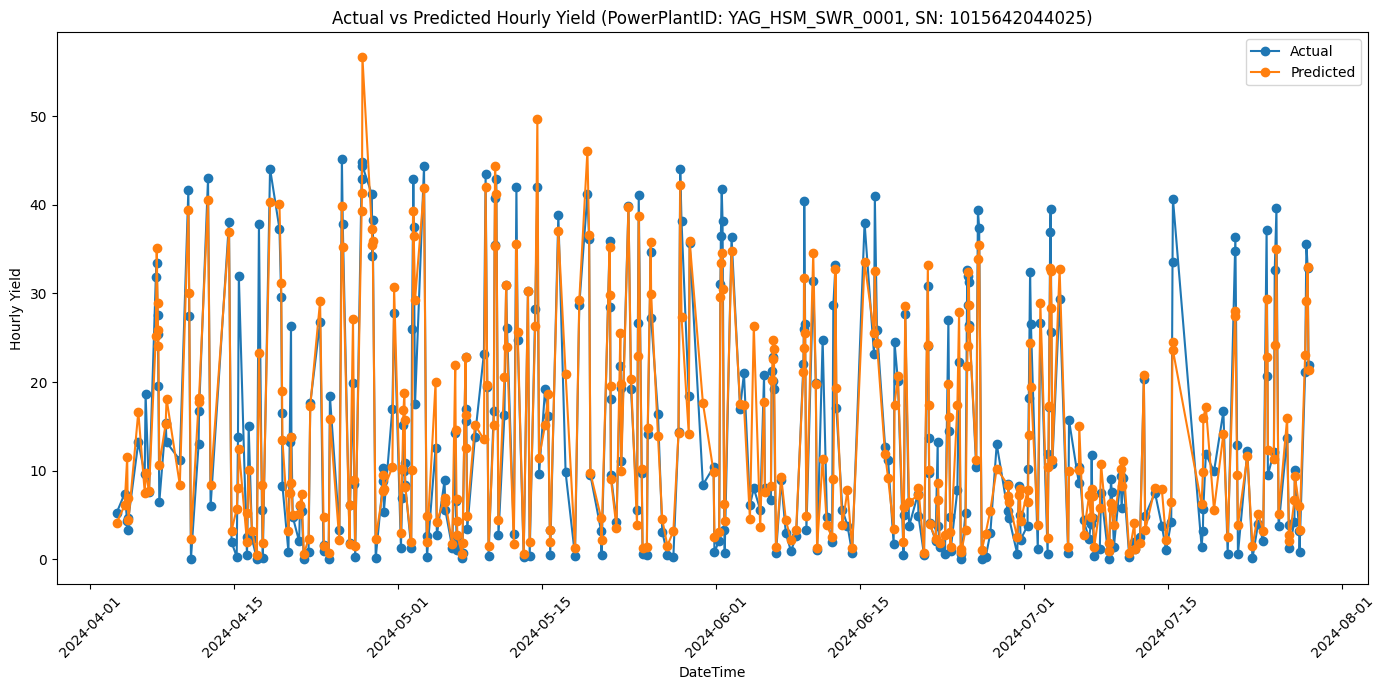

Mean Squared Error (Daily): 19.145211699959656
Root Mean Squared Error (Daily): 4.375524162881478
Mean Absolute Error (Daily): 2.6631228711792576
R-squared (Daily): 0.8618063725204024
Mean Absolute Percentage Error (Daily): 118.42848155739331%
Mean Bias Deviation (Daily): 0.7937061719110976


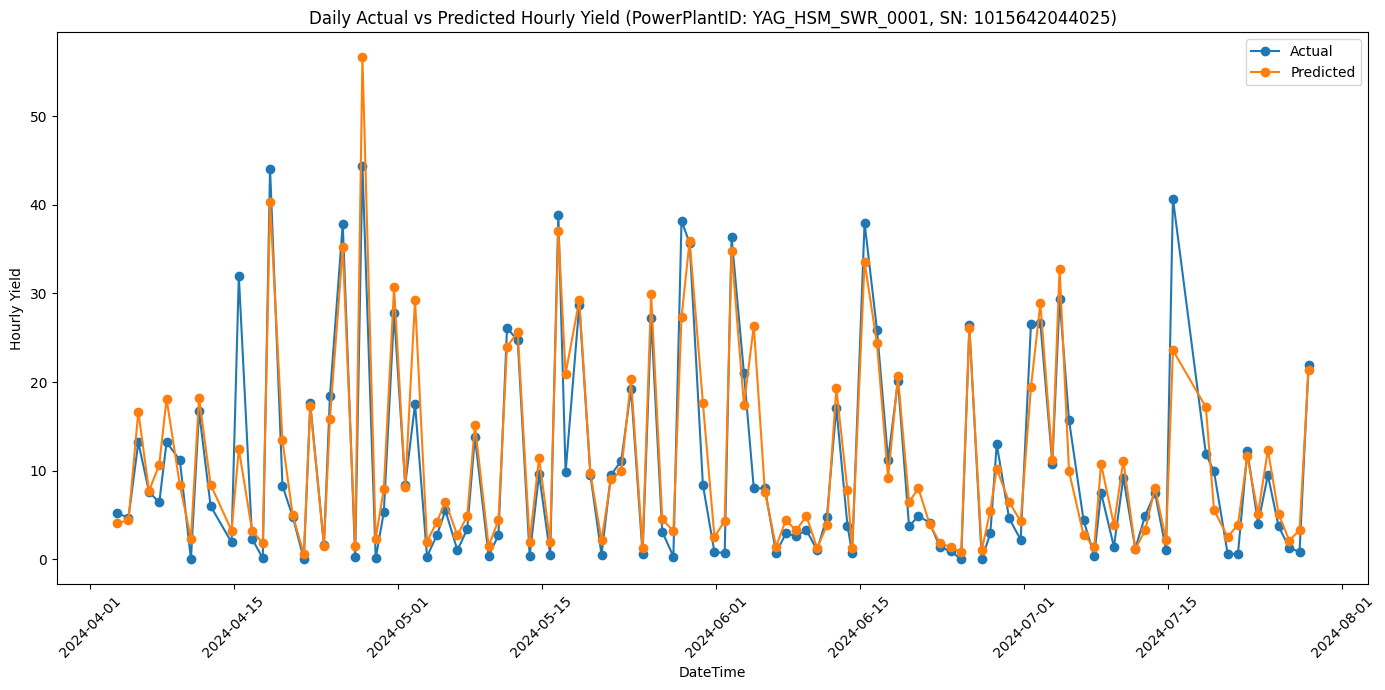

Inverter data for PowerPlantID: YAG_HSM_SWR_0001, SN: 1015642044102
       PowerPlantID             SN            datetime  DYield_diff  \
0  YAG_HSM_SWR_0001  1015642044102 2024-04-02 12:00:00         82.3   
1  YAG_HSM_SWR_0001  1015642044102 2024-04-02 13:00:00         29.2   
2  YAG_HSM_SWR_0001  1015642044102 2024-04-02 14:00:00         23.2   
3  YAG_HSM_SWR_0001  1015642044102 2024-04-02 15:00:00         12.0   
4  YAG_HSM_SWR_0001  1015642044102 2024-04-02 16:00:00          6.4   

             crt_dttm     solarpower_sn  rn1 sky   t1h   reh  rn1v  wsd  hour  \
0 2024-04-02 11:55:03  YAG_HSM_SWR_0001  0.0   4  19.0  53.0   0.0  2.9    12   
1 2024-04-02 12:55:03  YAG_HSM_SWR_0001  0.0   4  19.4  52.0   0.0  3.6    13   
2 2024-04-02 13:55:03  YAG_HSM_SWR_0001  0.0   4  19.5  60.0   0.0  4.0    14   
3 2024-04-02 14:55:03  YAG_HSM_SWR_0001  0.0   4  18.3  68.0   0.0  4.8    15   
4 2024-04-02 15:55:03  YAG_HSM_SWR_0001  0.0   4  17.8  72.0   0.0  2.3    16   

   month  day  
0 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    2.9s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    3.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    0.1s finished


PowerPlantID: YAG_HSM_SWR_0001, SN: 1015642044102
Mean Squared Error: 20.46615777292579
Root Mean Squared Error: 4.523953776612421
Mean Absolute Error: 3.0275531032771026
R-squared: 0.8911718638275525
Mean Absolute Percentage Error: 74.19172487077329%
Mean Bias Deviation: -0.08112340602287231


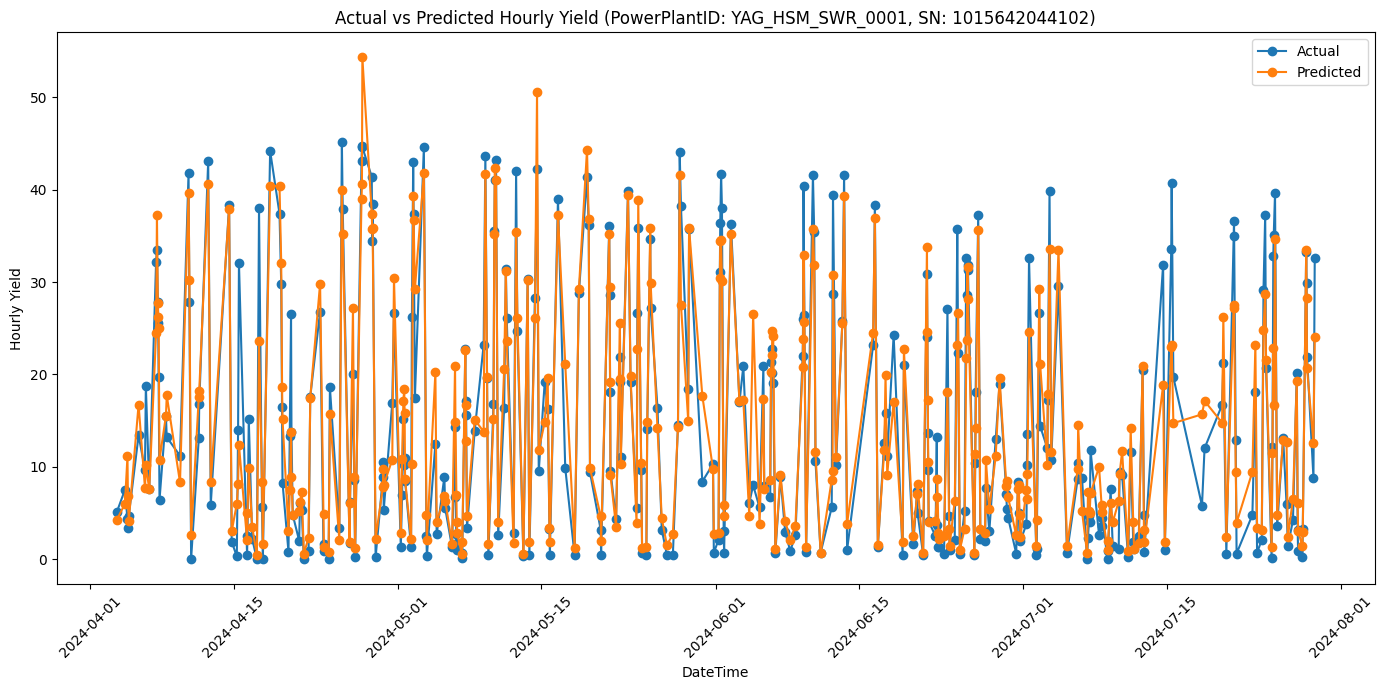

Mean Squared Error (Daily): 18.181768973841518
Root Mean Squared Error (Daily): 4.264008556961573
Mean Absolute Error (Daily): 2.6499833361604894
R-squared (Daily): 0.8665335481310918
Mean Absolute Percentage Error (Daily): 93.24027168496931%
Mean Bias Deviation (Daily): 0.8610527462392886


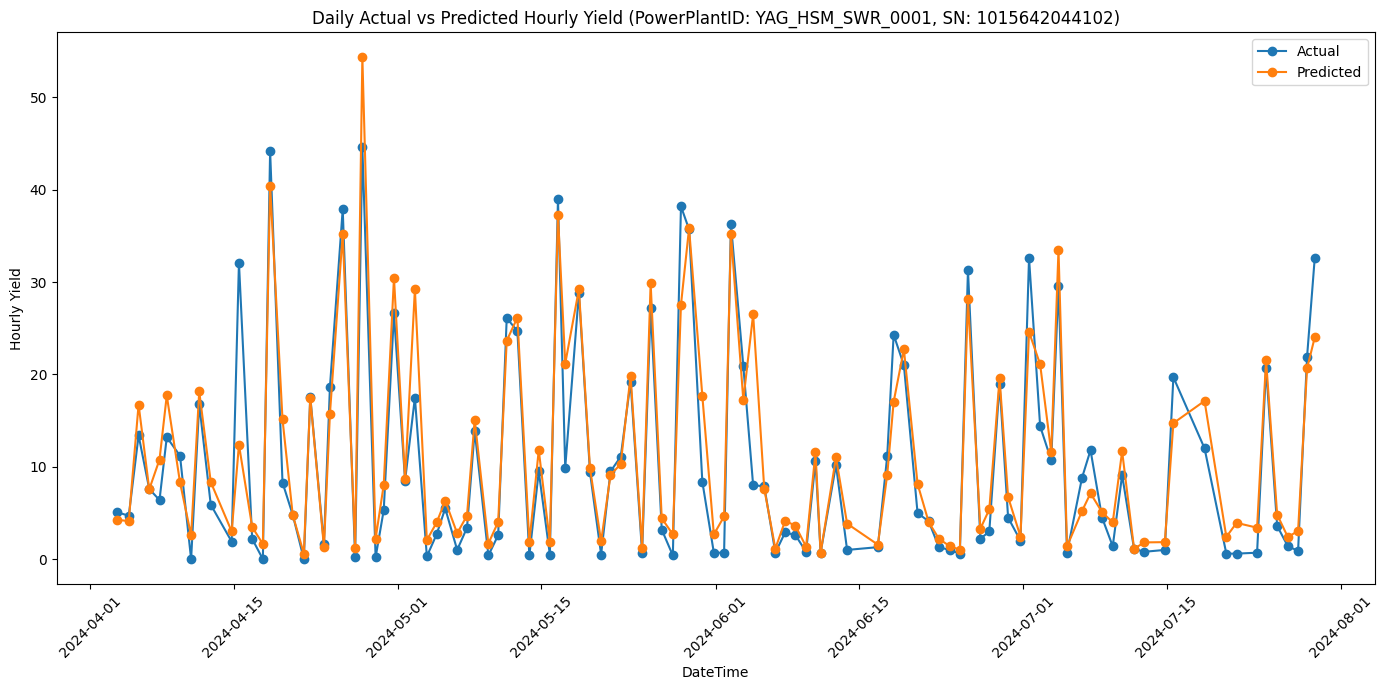

Inverter data for PowerPlantID: YAG_HSM_SWR_0001, SN: 1015642044093
       PowerPlantID             SN            datetime  DYield_diff  \
0  YAG_HSM_SWR_0001  1015642044093 2024-04-02 12:00:00         78.3   
1  YAG_HSM_SWR_0001  1015642044093 2024-04-02 13:00:00         27.7   
2  YAG_HSM_SWR_0001  1015642044093 2024-04-02 14:00:00         22.1   
3  YAG_HSM_SWR_0001  1015642044093 2024-04-02 15:00:00         11.5   
4  YAG_HSM_SWR_0001  1015642044093 2024-04-02 16:00:00          6.0   

             crt_dttm     solarpower_sn  rn1 sky   t1h   reh  rn1v  wsd  hour  \
0 2024-04-02 11:55:06  YAG_HSM_SWR_0001  0.0   4  19.0  53.0   0.0  2.9    12   
1 2024-04-02 12:55:06  YAG_HSM_SWR_0001  0.0   4  19.4  52.0   0.0  3.6    13   
2 2024-04-02 13:55:06  YAG_HSM_SWR_0001  0.0   4  19.5  60.0   0.0  4.0    14   
3 2024-04-02 14:55:06  YAG_HSM_SWR_0001  0.0   4  18.3  68.0   0.0  4.8    15   
4 2024-04-02 15:55:06  YAG_HSM_SWR_0001  0.0   4  17.8  72.0   0.0  2.3    16   

   month  day  
0 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    2.9s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    3.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    0.1s finished


PowerPlantID: YAG_HSM_SWR_0001, SN: 1015642044093
Mean Squared Error: 16.382566596551705
Root Mean Squared Error: 4.047538337872997
Mean Absolute Error: 2.8240142088067475
R-squared: 0.9000703800267578
Mean Absolute Percentage Error: 96.40771836198341%
Mean Bias Deviation: 0.2710951929002946


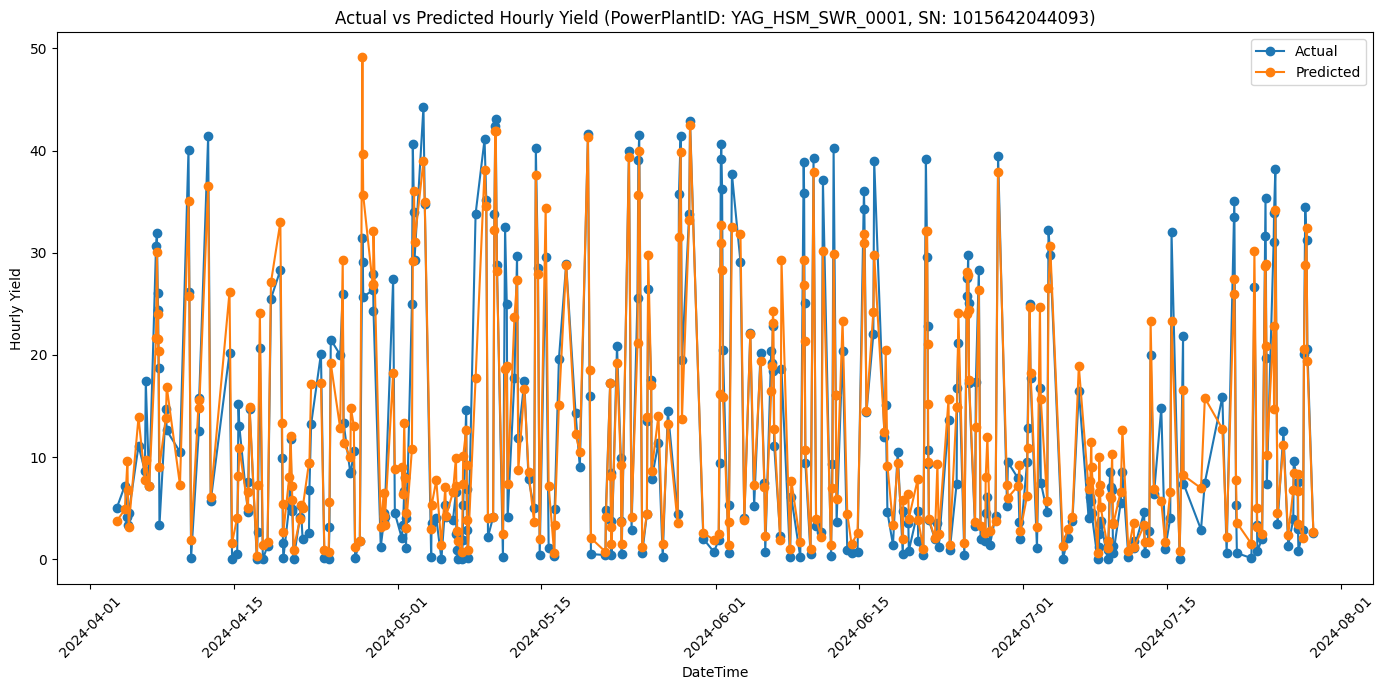

Mean Squared Error (Daily): 12.642240699780247
Root Mean Squared Error (Daily): 3.5555928759885105
Mean Absolute Error (Daily): 2.4341557423008706
R-squared (Daily): 0.8938581033359989
Mean Absolute Percentage Error (Daily): 149.53542743355703%
Mean Bias Deviation (Daily): 0.8737151750224911


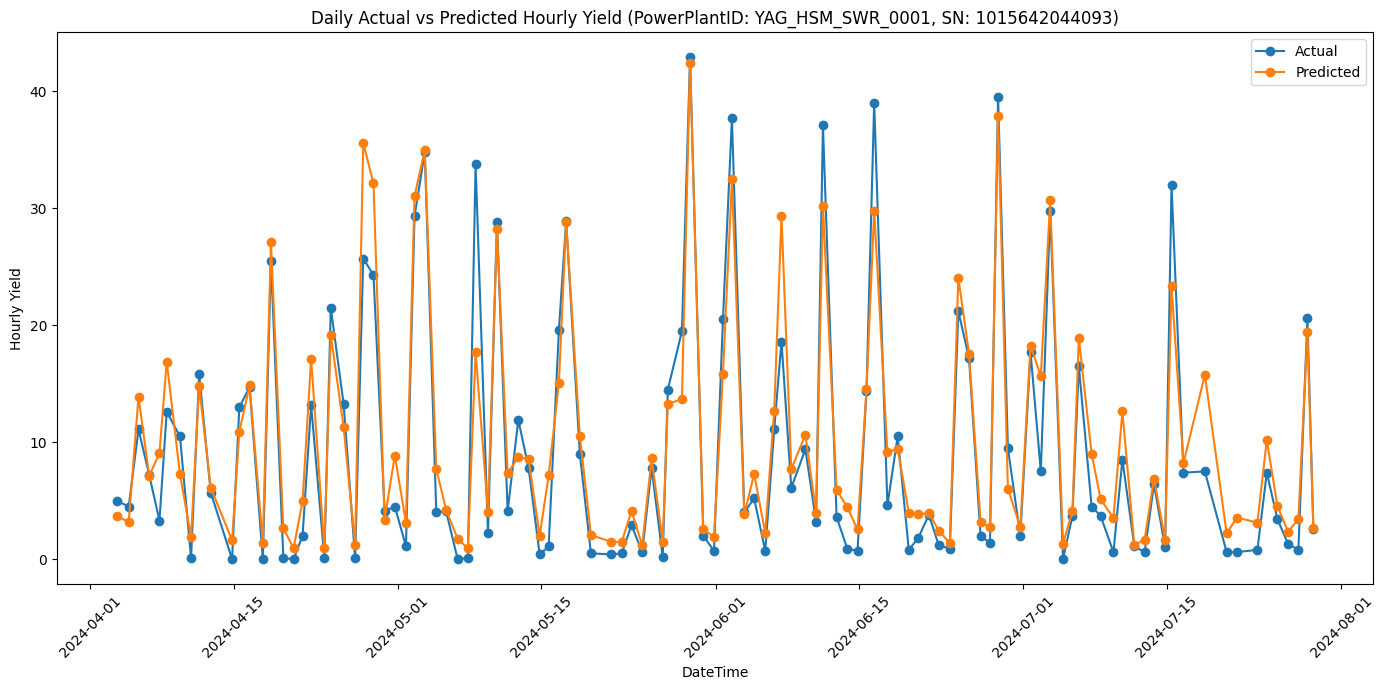

Inverter data for PowerPlantID: GJM_GSG_SGD_0001, SN: 1018282223012
       PowerPlantID             SN            datetime  DYield_diff  \
0  GJM_GSG_SGD_0001  1018282223012 2024-03-21 13:00:00        140.0   
1  GJM_GSG_SGD_0001  1018282223012 2024-03-21 14:00:00         44.6   
2  GJM_GSG_SGD_0001  1018282223012 2024-03-21 15:00:00         43.0   
3  GJM_GSG_SGD_0001  1018282223012 2024-03-21 16:00:00         37.6   
4  GJM_GSG_SGD_0001  1018282223012 2024-03-21 17:00:00         28.6   

             crt_dttm     solarpower_sn  rn1 sky   t1h   reh  rn1v  wsd  hour  \
0 2024-03-21 12:55:00  GJM_GSG_SGD_0001  0.0   1   9.0  40.0   0.0  1.0    13   
1 2024-03-21 13:55:00  GJM_GSG_SGD_0001  0.0   1  11.2  35.0   0.0  1.2    14   
2 2024-03-21 14:55:00  GJM_GSG_SGD_0001  0.0   1  12.4  31.0   0.0  2.1    15   
3 2024-03-21 15:55:00  GJM_GSG_SGD_0001  0.0   1  12.2  29.0   0.0  2.9    16   
4 2024-03-21 16:55:00  GJM_GSG_SGD_0001  0.0   1  10.2  37.0   0.0  2.4    17   

   month  day  
0 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    2.0s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    3.1s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    0.1s finished


PowerPlantID: GJM_GSG_SGD_0001, SN: 1018282223012
Mean Squared Error: 49.34086307304613
Root Mean Squared Error: 7.024305166566023
Mean Absolute Error: 3.3373818583125265
R-squared: 0.7893995013471676
Mean Absolute Percentage Error: 97.48108221480486%
Mean Bias Deviation: -0.5995234936214627


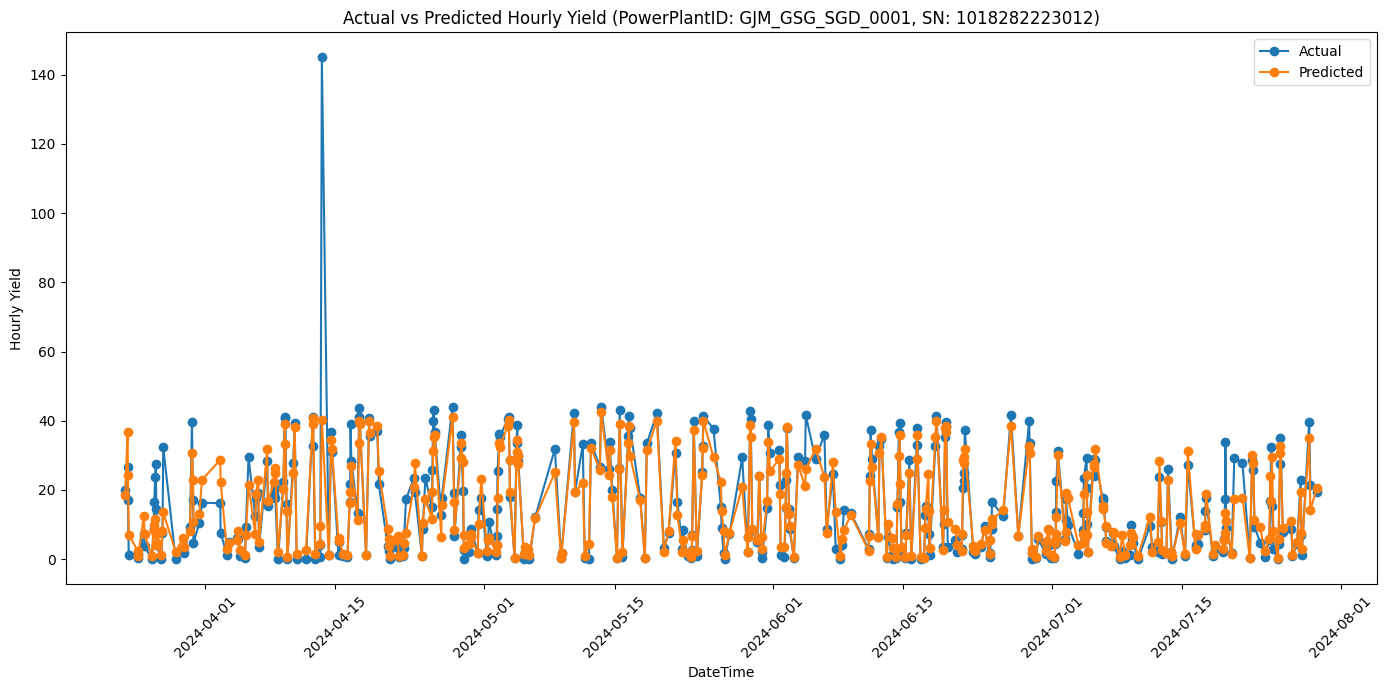

Mean Squared Error (Daily): 106.66083424034905
Root Mean Squared Error (Daily): 10.327673224901583
Mean Absolute Error (Daily): 3.775663454984085
R-squared (Daily): 0.6680699784790813
Mean Absolute Percentage Error (Daily): 163.02435437958874%
Mean Bias Deviation (Daily): -0.9096129522819262


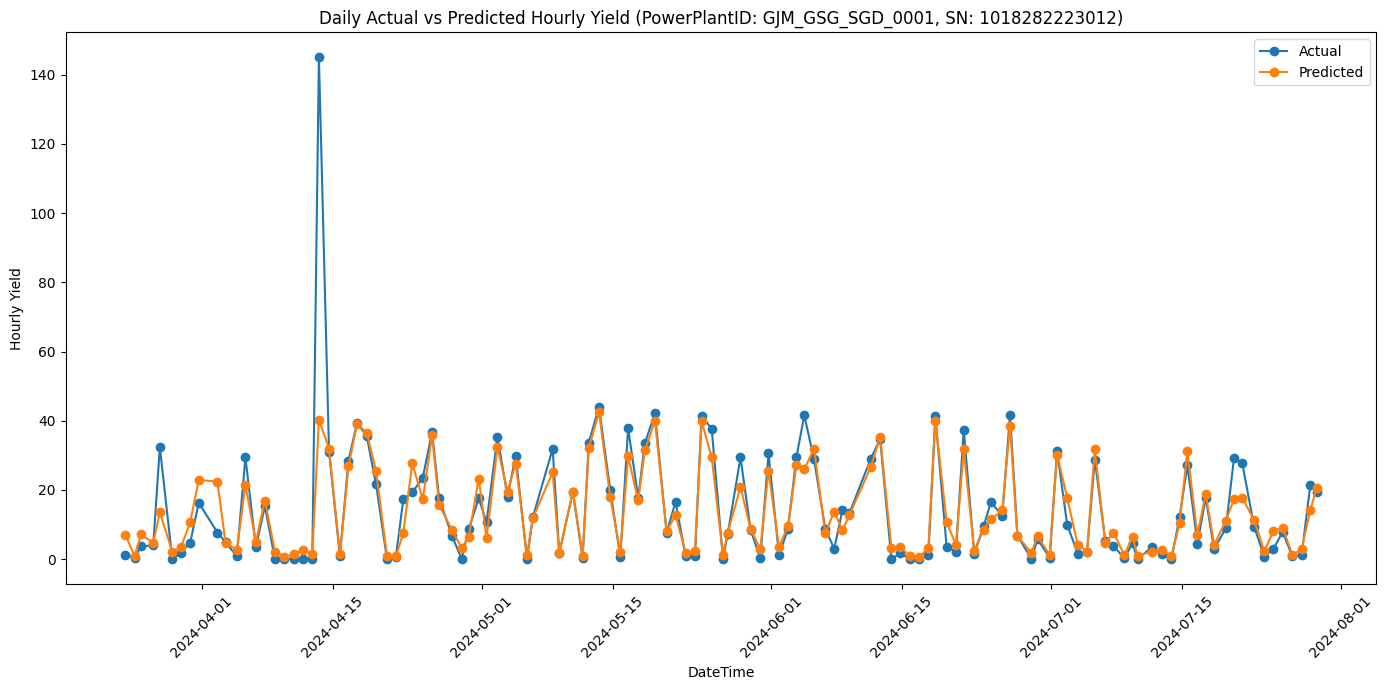

Inverter data for PowerPlantID: GJM_GSG_SGD_0001, SN: 1018282225009
       PowerPlantID             SN            datetime  DYield_diff  \
0  GJM_GSG_SGD_0001  1018282225009 2024-03-21 13:00:00        124.8   
1  GJM_GSG_SGD_0001  1018282225009 2024-03-21 14:00:00         40.1   
2  GJM_GSG_SGD_0001  1018282225009 2024-03-21 15:00:00         38.6   
3  GJM_GSG_SGD_0001  1018282225009 2024-03-21 16:00:00         33.9   
4  GJM_GSG_SGD_0001  1018282225009 2024-03-21 17:00:00         25.7   

             crt_dttm     solarpower_sn  rn1 sky   t1h   reh  rn1v  wsd  hour  \
0 2024-03-21 12:55:03  GJM_GSG_SGD_0001  0.0   1   9.0  40.0   0.0  1.0    13   
1 2024-03-21 13:55:03  GJM_GSG_SGD_0001  0.0   1  11.2  35.0   0.0  1.2    14   
2 2024-03-21 14:55:03  GJM_GSG_SGD_0001  0.0   1  12.4  31.0   0.0  2.1    15   
3 2024-03-21 15:55:03  GJM_GSG_SGD_0001  0.0   1  12.2  29.0   0.0  2.9    16   
4 2024-03-21 16:55:03  GJM_GSG_SGD_0001  0.0   1  10.2  37.0   0.0  2.4    17   

   month  day  
0 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    2.0s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    3.2s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1500 out of 1500 | elapsed:    0.1s finished


PowerPlantID: GJM_GSG_SGD_0001, SN: 1018282225009
Mean Squared Error: 41.34289858310624
Root Mean Squared Error: 6.429844366942814
Mean Absolute Error: 3.0903206734870876
R-squared: 0.7783411062523795
Mean Absolute Percentage Error: 79.85273982267495%
Mean Bias Deviation: -0.43102073070545727


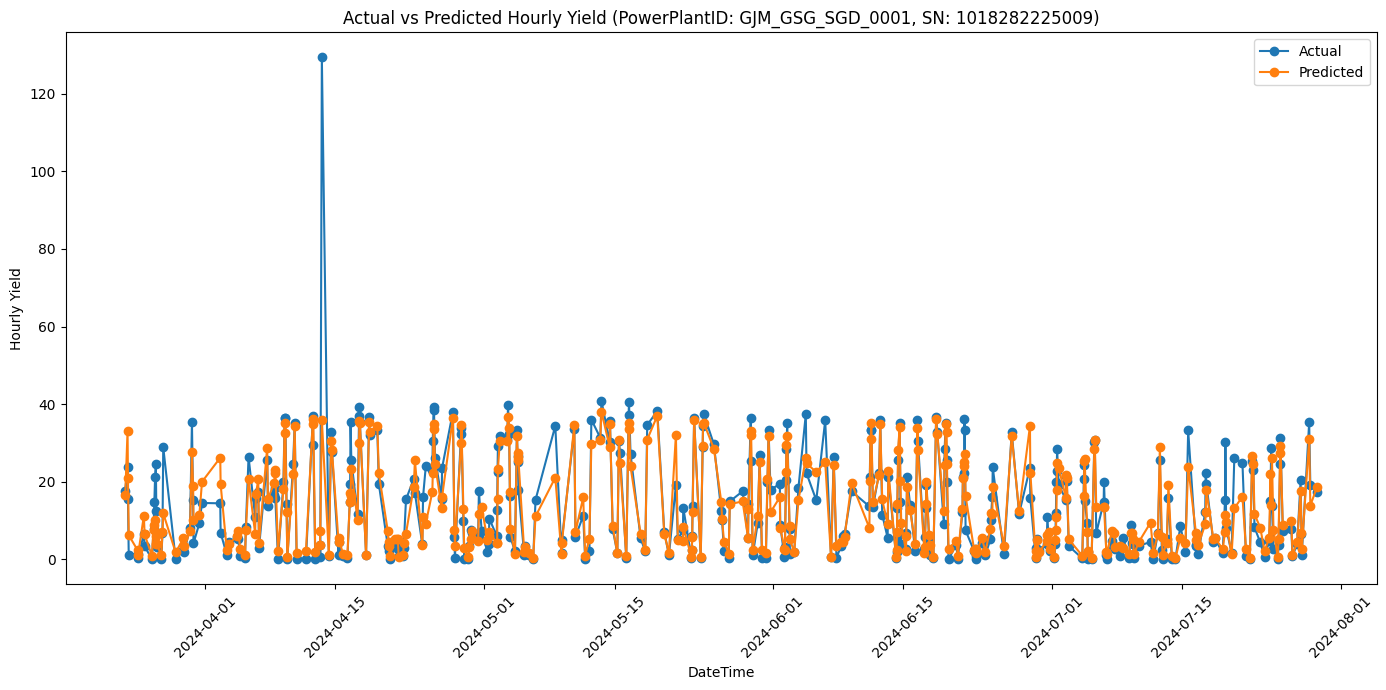

Mean Squared Error (Daily): 89.28381225868837
Root Mean Squared Error (Daily): 9.449011178884717
Mean Absolute Error (Daily): 3.7690598262791712
R-squared (Daily): 0.6467993550629045
Mean Absolute Percentage Error (Daily): 149.5502706408418%
Mean Bias Deviation (Daily): -0.6147928251586897


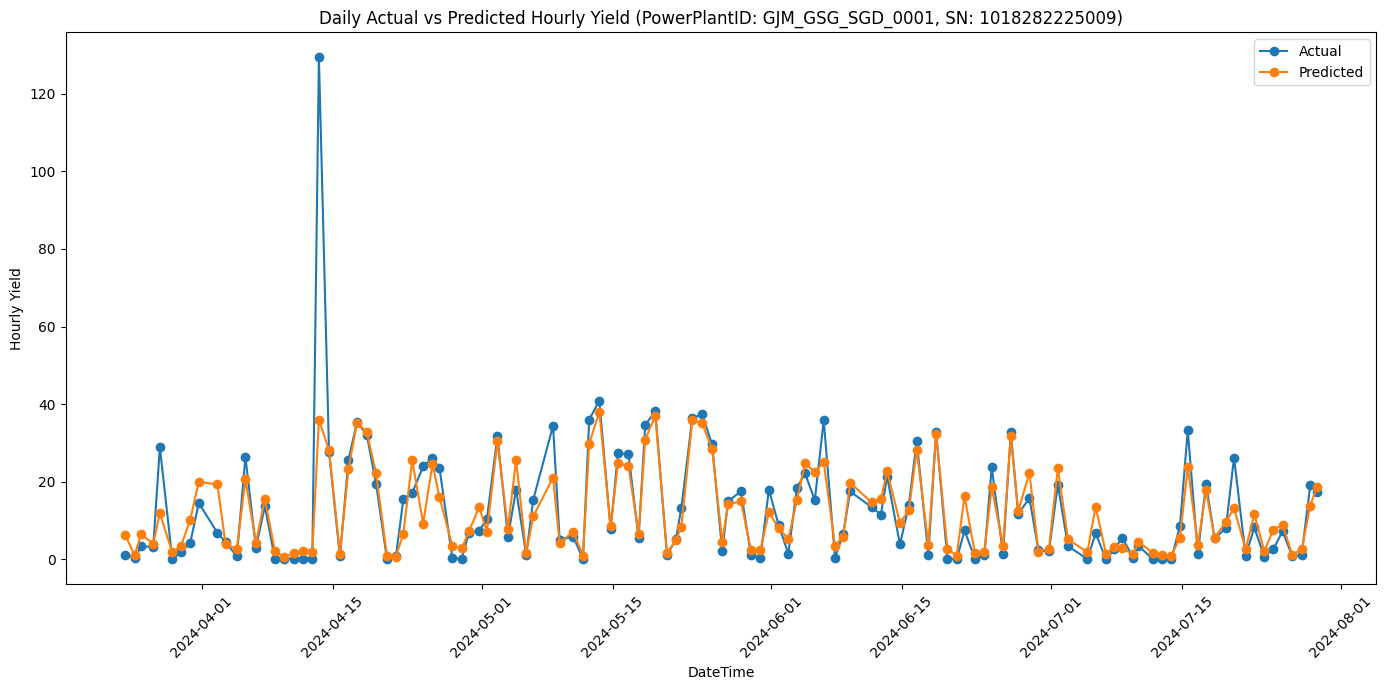

Results for YAG_HSM_SWR_0001_1015642044025:
               DateTime      PowerPlantID             SN            crt_dttm  \
0   2024-04-25 13:00:00  YAG_HSM_SWR_0001  1015642044025 2024-04-25 12:55:00   
1   2024-05-01 10:00:00  YAG_HSM_SWR_0001  1015642044025 2024-05-01 09:55:00   
2   2024-05-01 07:00:00  YAG_HSM_SWR_0001  1015642044025 2024-05-01 06:55:00   
3   2024-05-05 13:00:00  YAG_HSM_SWR_0001  1015642044025 2024-05-05 12:55:00   
4   2024-07-14 10:00:00  YAG_HSM_SWR_0001  1015642044025 2024-07-14 09:55:00   
..                  ...               ...            ...                 ...   
346 2024-07-21 18:00:00  YAG_HSM_SWR_0001  1015642044025 2024-07-21 17:55:00   
347 2024-05-21 18:00:00  YAG_HSM_SWR_0001  1015642044025 2024-05-21 17:55:00   
348 2024-05-03 20:00:00  YAG_HSM_SWR_0001  1015642044025 2024-05-03 19:30:00   
349 2024-06-25 12:00:00  YAG_HSM_SWR_0001  1015642044025 2024-06-25 11:55:00   
350 2024-06-07 08:00:00  YAG_HSM_SWR_0001  1015642044025 2024-06-07 07:55:00

In [80]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import re
import joblib

# 데이터 로드
solar_data_path = './태양광 발전량 예측 폴더/태양광_발전량데이터_24-07-29-11시.csv'
weather_data_path = './태양광 발전량 예측 폴더/태양광_날씨데이터_24-07-29-11시.csv'

solar_df = pd.read_csv(solar_data_path)
weather_df = pd.read_csv(weather_data_path)

# 태양광 데이터 전처리
solar_df['crt_dttm'] = pd.to_datetime(solar_df['crt_dttm'], errors='coerce') # object를 datetime64[ns]로, coerce: 변환 실패 → NaT
solar_df['datetime'] = solar_df['crt_dttm'].dt.floor('h') # 1시간 단위로 내림
solar_df['date'] = solar_df['crt_dttm'].dt.date # 년월일, 2022-12-26
solar_df['hour'] = solar_df['crt_dttm'].dt.hour # 시각
solar_df['month'] = solar_df['crt_dttm'].dt.month # 월
solar_df['day'] = solar_df['crt_dttm'].dt.day # 일

# 각 시간별 마지막 데이터 선택
hourly_solar = solar_df.sort_values(by=['crt_dttm']).groupby(['PowerPlantID', 'SN', 'datetime']).last().reset_index() # 그룹의 마지막 행 선택, first(): 그룹의 첫 행 선택

# 각 시간별 발전량 계산
hourly_solar['date'] = hourly_solar['datetime'].dt.date  # 날짜 열 추가, 중복 코드로 보임 solar_df에서 date 열 생성함.
hourly_solar['DYield_diff'] = hourly_solar.groupby(['PowerPlantID', 'SN', 'date'])['DYield'].diff().fillna(hourly_solar['DYield']) # .diff(): 이전 값과의 차이

# 날씨 데이터 전처리
weather_df['base_time'] = weather_df['base_time'].apply(lambda x: f"{int(x):04d}") # 4자리 고정 및 obj, 0 -> '0000'
weather_df['datetime'] = pd.to_datetime(weather_df['base_date'].astype(str) + weather_df['base_time'], format='%Y%m%d%H%M') # 2023-06-27 10:00:00
weather_df['datetime'] = weather_df['datetime'].dt.floor('h') # 1시간 단위로 내림

# 필요한 컬럼 선택
solar_selected = hourly_solar[['PowerPlantID', 'SN', 'datetime', 'DYield_diff', 'crt_dttm']]
weather_selected = weather_df[['solarpower_sn', 'datetime', 'rn1', 'sky', 't1h', 'reh', 'rn1v', 'wsd']]

# 시간 차이를 두고 데이터 병합
merged_df = pd.merge(solar_selected, weather_selected, left_on=['PowerPlantID', 'datetime'], right_on=['solarpower_sn', 'datetime'], how='inner') # PowerPlantID랑 solarpower_sn랑 같은 키로 간주하여 innerjoin
merged_df['datetime'] = merged_df['datetime'] + pd.Timedelta(hours=1) # .last() 데이터들이 대부분 55분짜리가 많은 그래서 1시간 뒤 데이터로 재해석

# rn1v에서 \N을 NaN으로 처리
merged_df['rn1v'] = merged_df['rn1v'].replace('\\N', np.nan).astype(float) # \N을 NaN으로 변경 후 type float으로 변경
merged_df['rn1v'].fillna(0, inplace=True) # NaN값 0으로 변경 inplace로

# 강수량 변환 함수
def convert_pcp(value):
    if '강수없음' in value:
        return 0.0
    elif '미만' in value:
        num = re.findall(r'\d+', value)
        if num:
            return float(num[0]) - 0.5 # 상한값보다 조금작은값으로 변환 1 -> 0.5, 3 -> 2.5
        else:
            return 0.0
    else:
        num = re.findall(r'\d+\.\d+|\d+', value) # 매칭되는 문자열을 전부 찾아서 list로 반환
        if num:
            return float(num[0]) # num의 type이 list
        else:
            return 0.0

merged_df['rn1'] = merged_df['rn1'].apply(convert_pcp)

# 피처 엔지니어링
merged_df['hour'] = merged_df['datetime'].dt.hour
merged_df['month'] = merged_df['datetime'].dt.month
merged_df['day'] = merged_df['datetime'].dt.day

# 인버터별로 데이터 나누기
inverters = {
    'YAG_HSM_SWR_0001': [1015642044025, 1015642044102, 1015642044093],
    'GJM_GSG_SGD_0001': [1018282223012, 1018282225009]
}

results_dict = {}

for plant_id, sn_list in inverters.items():
    for sn in sn_list:
        inverter_data = merged_df[(merged_df['PowerPlantID'] == plant_id) & (merged_df['SN'] == sn)].reset_index(drop=True)

        if len(inverter_data) < 2:  # 샘플 수가 너무 적으면 다음 인버터로 넘어감
            print(f"Not enough data for PowerPlantID: {plant_id}, SN: {sn}. Skipping this inverter. Sample: {len(inverter_data)}")
            continue

        # 데이터 확인
        print(f'Inverter data for PowerPlantID: {plant_id}, SN: {sn}')
        print(inverter_data.head())

        # 필요한 피처 선택
        X = inverter_data[['rn1', 'sky', 't1h', 'reh', 'rn1v', 'wsd', 'hour', 'month', 'day']]
        y = inverter_data['DYield_diff']

        # 데이터 분리
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # 모델 학습
        model = RandomForestRegressor(max_depth=20, max_features='sqrt', n_estimators=1500, random_state=42, verbose=1)
        model.fit(X_train, y_train)

        # 모델 저장
        model_filename = f'./태양광 발전량 예측 폴더/model_{plant_id}_{sn}.joblib'
        joblib.dump(model, model_filename)

        # 예측
        y_pred = model.predict(X_test)

         # 평가
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # 실제 값이 0이 아닌 데이터만 사용하여 MAPE 계산
        non_zero_actuals = y_test != 0
        mape = np.mean(np.abs((y_test[non_zero_actuals] - y_pred[non_zero_actuals]) / y_test[non_zero_actuals])) * 100

        mbd = np.mean(y_pred - y_test)
        print(f'PowerPlantID: {plant_id}, SN: {sn}')
        print(f'Mean Squared Error: {mse}')
        print(f'Root Mean Squared Error: {rmse}')
        print(f'Mean Absolute Error: {mae}')
        print(f'R-squared: {r2}')
        print(f'Mean Absolute Percentage Error: {mape}%')
        print(f'Mean Bias Deviation: {mbd}')

        # 실제값과 예측값 데이터프레임 생성
        results_df = pd.DataFrame({
            'DateTime': inverter_data.loc[X_test.index, 'datetime'].values,
            'PowerPlantID': inverter_data.loc[X_test.index, 'PowerPlantID'].values,
            'SN': inverter_data.loc[X_test.index, 'SN'].values,
            'crt_dttm': inverter_data.loc[X_test.index, 'crt_dttm'].values,
            'Actual': y_test.values,
            'Predicted': y_pred
        }).reset_index(drop=True)

        results_dict[f'{plant_id}_{sn}'] = results_df

        # 데이터프레임 정렬
        results_df = results_df.sort_values(by='DateTime').reset_index(drop=True)

        # 시각화
        plt.figure(figsize=(14, 7))
        plt.plot(results_df['DateTime'], results_df['Actual'], label='Actual', marker='o')
        plt.plot(results_df['DateTime'], results_df['Predicted'], label='Predicted', marker='o')
        plt.legend()
        plt.xlabel('DateTime')
        plt.ylabel('Hourly Yield')
        plt.title(f'Actual vs Predicted Hourly Yield (PowerPlantID: {plant_id}, SN: {sn})')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # DateTime에서 날짜만 추출하는 컬럼 추가
        results_df['Date'] = results_df['DateTime'].dt.date

        # 각 날짜별로 마지막 시간 데이터를 추출
        last_results_df = results_df.sort_values(by=['DateTime']).groupby(['PowerPlantID', 'SN', 'Date']).last().reset_index()

        # 불필요한 Date 컬럼 제거
        last_results_df = last_results_df.drop(columns=['Date'])
        last_results_df = last_results_df.sort_values(by='DateTime').reset_index(drop=True)

        # 실제 값이 0이 아닌 데이터만 사용하여 MAPE 계산
        non_zero_actuals = last_results_df[last_results_df['Actual'] != 0]

        # 평가
        mse = mean_squared_error(last_results_df['Actual'], last_results_df['Predicted'])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(last_results_df['Actual'], last_results_df['Predicted'])
        r2 = r2_score(last_results_df['Actual'], last_results_df['Predicted'])
        mape = np.mean(np.abs((non_zero_actuals['Actual'] - non_zero_actuals['Predicted']) / non_zero_actuals['Actual'])) * 100
        mbd = np.mean(last_results_df['Predicted'] - last_results_df['Actual'])
        print(f'Mean Squared Error (Daily): {mse}')
        print(f'Root Mean Squared Error (Daily): {rmse}')
        print(f'Mean Absolute Error (Daily): {mae}')
        print(f'R-squared (Daily): {r2}')
        print(f'Mean Absolute Percentage Error (Daily): {mape}%')
        print(f'Mean Bias Deviation (Daily): {mbd}')

        # 시각화 (Daily)
        plt.figure(figsize=(14, 7))
        plt.plot(last_results_df['DateTime'], last_results_df['Actual'], label='Actual', marker='o')
        plt.plot(last_results_df['DateTime'], last_results_df['Predicted'], label='Predicted', marker='o')
        plt.legend()
        plt.xlabel('DateTime')
        plt.ylabel('Hourly Yield')
        plt.title(f'Daily Actual vs Predicted Hourly Yield (PowerPlantID: {plant_id}, SN: {sn})')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 각 인버터별로 저장된 결과를 확인할 수 있습니다.
for key, df in results_dict.items():
    df['Difference'] = df['Actual'] - df['Predicted']
    df['Accuracy'] = np.where(df['Actual'] == 0, 0, (1 - abs(df['Difference']) / abs(df['Actual'])) * 100)
    print(f"Results for {key}:")
    print(df)

    # # 인버터별 결과를 개별 파일로 저장
    # df.to_csv(f'results_{key}.csv', index=False)

Model LightGBM으로 변경 및 시계열 데이터에 맞게 random_split 하지 않음


Inverter data for PowerPlantID: YAG_HSM_SWR_0001, SN: 1015642044025
       PowerPlantID             SN            datetime  DYield_diff  \
0  YAG_HSM_SWR_0001  1015642044025 2024-04-04 10:00:00          7.2   
1  YAG_HSM_SWR_0001  1015642044025 2024-04-04 11:00:00          7.8   
2  YAG_HSM_SWR_0001  1015642044025 2024-04-04 12:00:00          4.5   
3  YAG_HSM_SWR_0001  1015642044025 2024-04-04 13:00:00          6.0   
4  YAG_HSM_SWR_0001  1015642044025 2024-04-04 14:00:00          8.0   

             crt_dttm     solarpower_sn  rn1  sky   t1h   reh  ...  day  \
0 2024-04-04 09:55:00  YAG_HSM_SWR_0001  0.0    3  12.9  95.0  ...    4   
1 2024-04-04 10:55:00  YAG_HSM_SWR_0001  0.0    4  14.2  91.0  ...    4   
2 2024-04-04 11:55:00  YAG_HSM_SWR_0001  0.0    3  14.4  83.0  ...    4   
3 2024-04-04 12:55:00  YAG_HSM_SWR_0001  0.0    4  13.9  95.0  ...    4   
4 2024-04-04 13:55:00  YAG_HSM_SWR_0001  0.0    4  15.4  87.0  ...    4   

       hour_sin  hour_cos  month_sin  month_cos  yiel

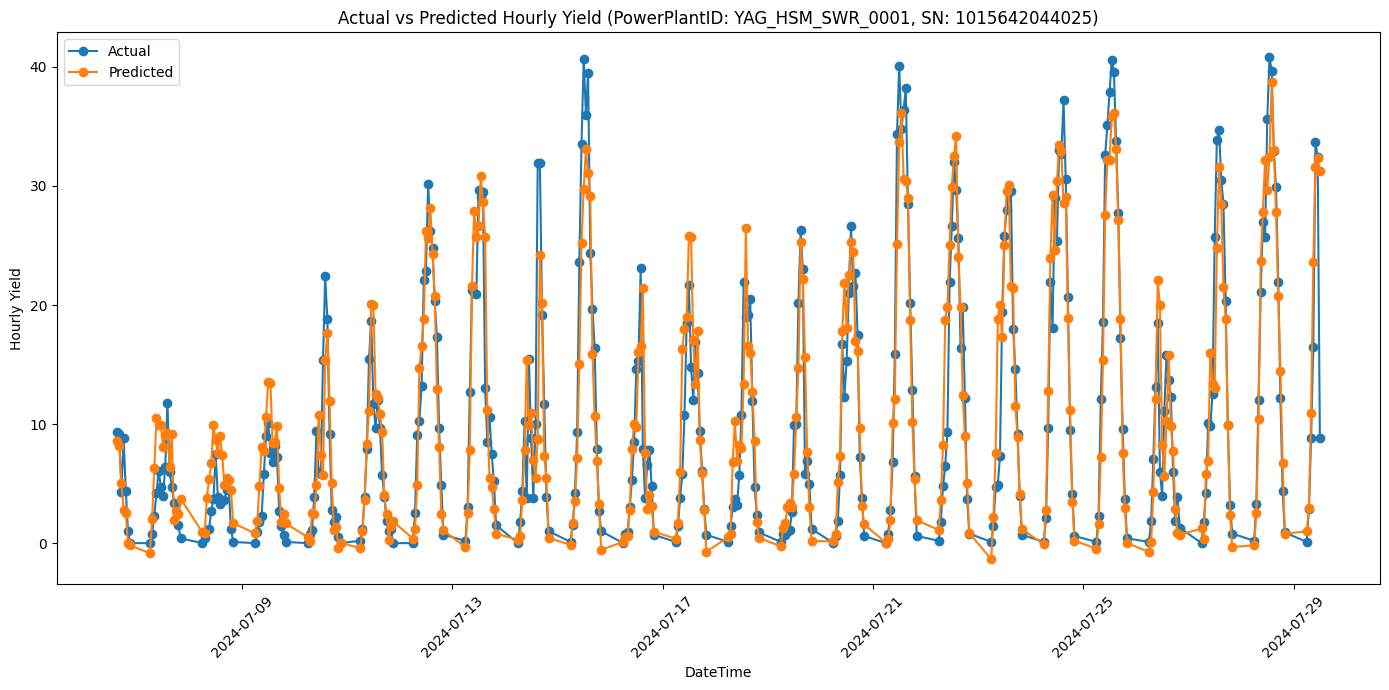

Daily MSE: 22.308198865436324
Daily RMSE: 4.723155604618201
Daily MAE: 1.7830268849323883
Daily R2: -6.931999892893239
Daily MAPE: 273.95142355159396%
Daily MBD: 1.0724956191472608


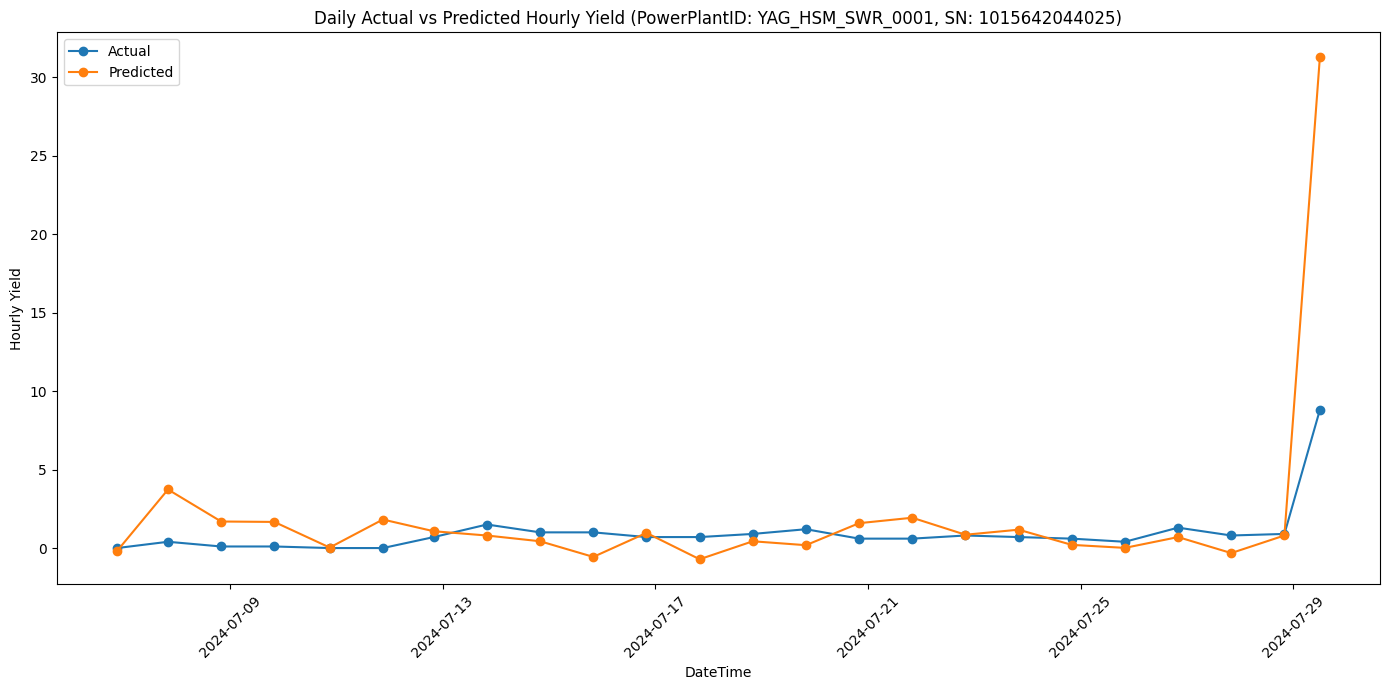


Inverter data for PowerPlantID: YAG_HSM_SWR_0001, SN: 1015642044102
       PowerPlantID             SN            datetime  DYield_diff  \
0  YAG_HSM_SWR_0001  1015642044102 2024-04-04 10:00:00          7.3   
1  YAG_HSM_SWR_0001  1015642044102 2024-04-04 11:00:00          7.8   
2  YAG_HSM_SWR_0001  1015642044102 2024-04-04 12:00:00          4.6   
3  YAG_HSM_SWR_0001  1015642044102 2024-04-04 13:00:00          6.2   
4  YAG_HSM_SWR_0001  1015642044102 2024-04-04 14:00:00          8.1   

             crt_dttm     solarpower_sn  rn1  sky   t1h   reh  ...  day  \
0 2024-04-04 09:55:03  YAG_HSM_SWR_0001  0.0    3  12.9  95.0  ...    4   
1 2024-04-04 10:55:03  YAG_HSM_SWR_0001  0.0    4  14.2  91.0  ...    4   
2 2024-04-04 11:55:03  YAG_HSM_SWR_0001  0.0    3  14.4  83.0  ...    4   
3 2024-04-04 12:55:03  YAG_HSM_SWR_0001  0.0    4  13.9  95.0  ...    4   
4 2024-04-04 13:55:03  YAG_HSM_SWR_0001  0.0    4  15.4  87.0  ...    4   

       hour_sin  hour_cos  month_sin  month_cos  yiel

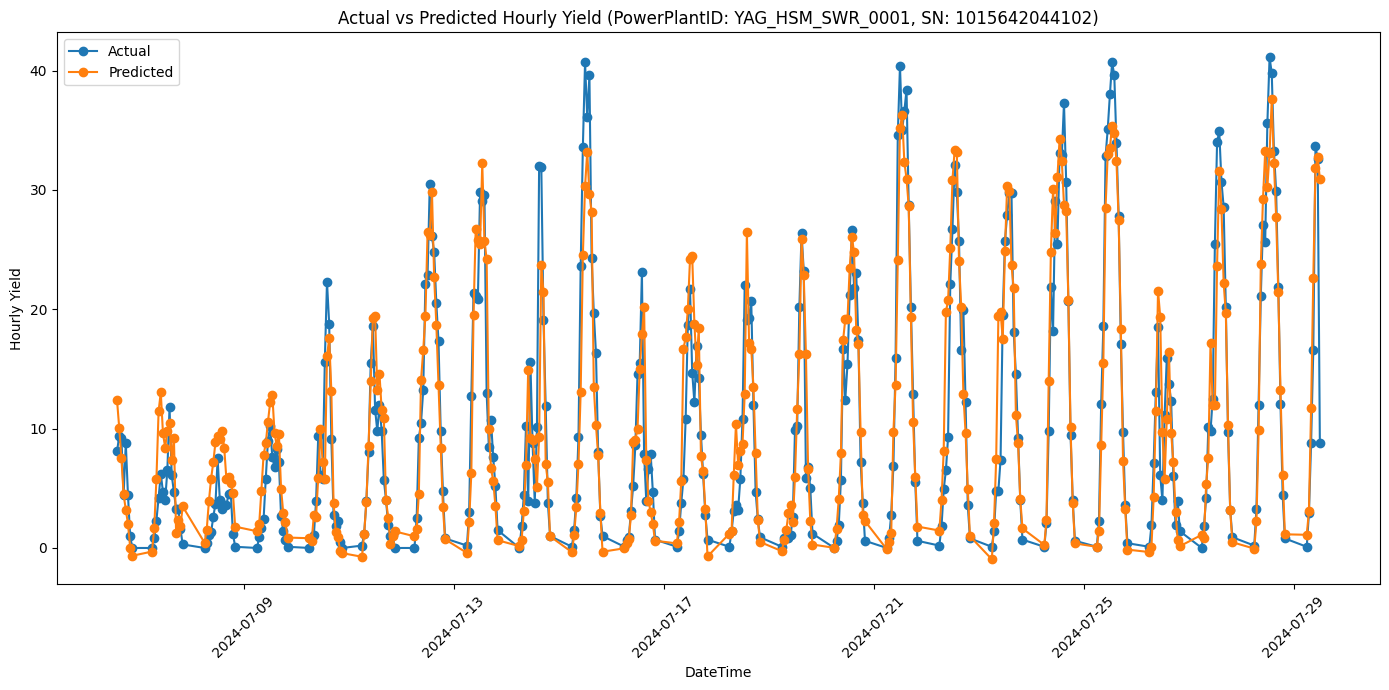

Daily MSE: 21.625381034867363
Daily RMSE: 4.650309778376852
Daily MAE: 1.7523003909874701
Daily R2: -6.672022786592441
Daily MAPE: 251.80450426346988%
Daily MBD: 1.0378059890596192


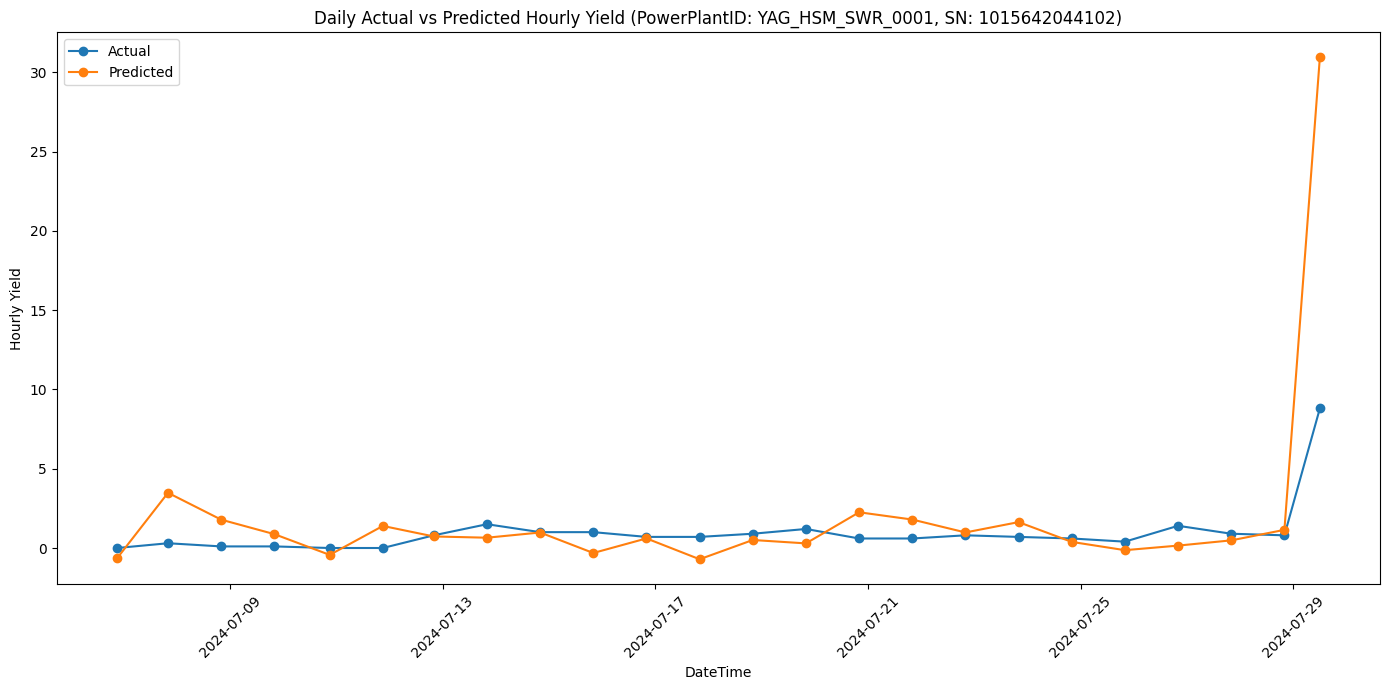


Inverter data for PowerPlantID: YAG_HSM_SWR_0001, SN: 1015642044093
       PowerPlantID             SN            datetime  DYield_diff  \
0  YAG_HSM_SWR_0001  1015642044093 2024-04-04 10:00:00          7.0   
1  YAG_HSM_SWR_0001  1015642044093 2024-04-04 11:00:00          7.5   
2  YAG_HSM_SWR_0001  1015642044093 2024-04-04 12:00:00          4.3   
3  YAG_HSM_SWR_0001  1015642044093 2024-04-04 13:00:00          5.8   
4  YAG_HSM_SWR_0001  1015642044093 2024-04-04 14:00:00          7.7   

             crt_dttm     solarpower_sn  rn1  sky   t1h   reh  ...  day  \
0 2024-04-04 09:55:06  YAG_HSM_SWR_0001  0.0    3  12.9  95.0  ...    4   
1 2024-04-04 10:55:06  YAG_HSM_SWR_0001  0.0    4  14.2  91.0  ...    4   
2 2024-04-04 11:55:06  YAG_HSM_SWR_0001  0.0    3  14.4  83.0  ...    4   
3 2024-04-04 12:55:06  YAG_HSM_SWR_0001  0.0    4  13.9  95.0  ...    4   
4 2024-04-04 13:55:06  YAG_HSM_SWR_0001  0.0    4  15.4  87.0  ...    4   

       hour_sin  hour_cos  month_sin  month_cos  yiel

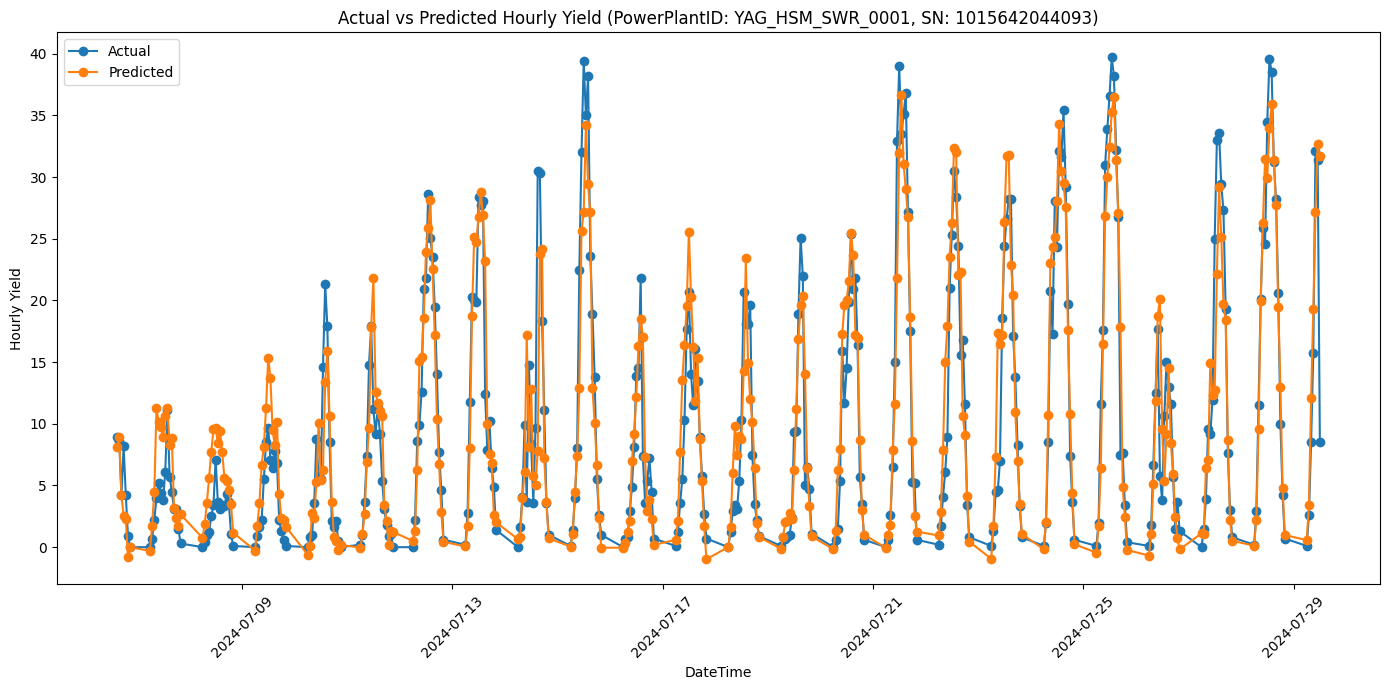

Daily MSE: 23.235966720490847
Daily RMSE: 4.820369977552641
Daily MAE: 1.6222624791682625
Daily R2: -7.854842161988744
Daily MAPE: 234.02674361181099%
Daily MBD: 1.0304082923746944


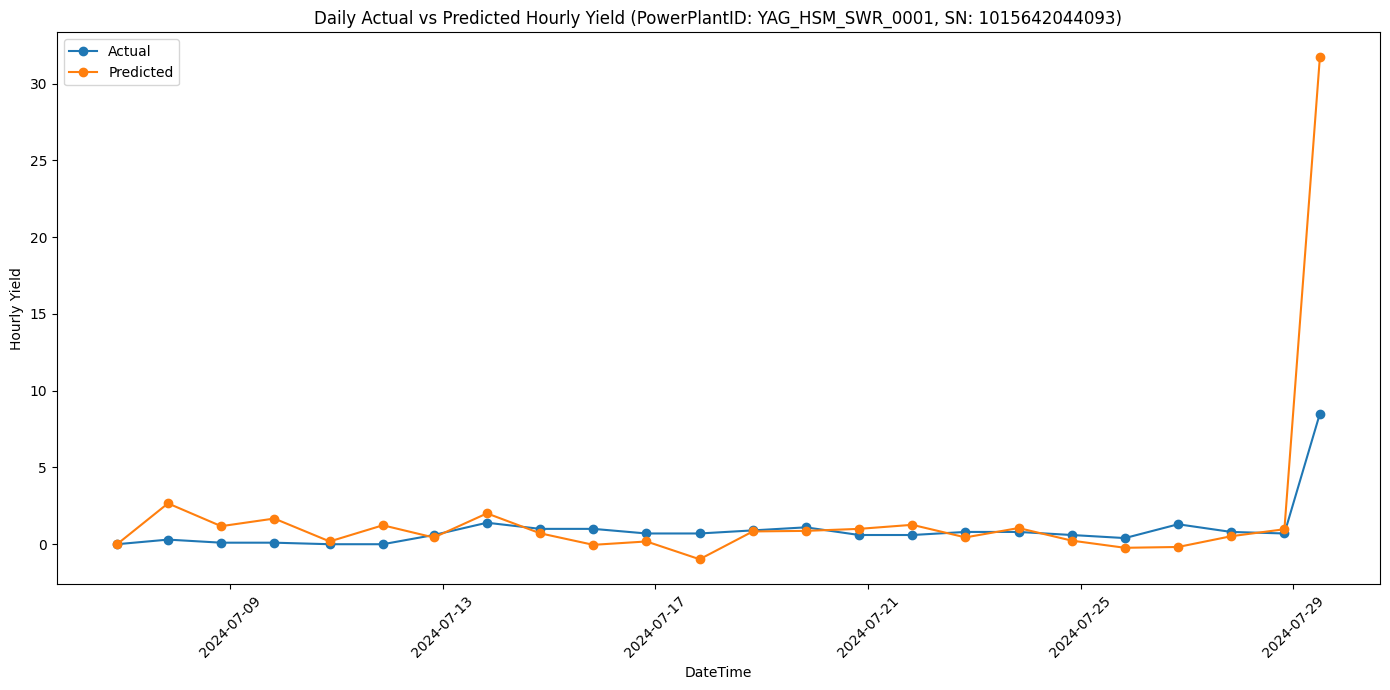


Inverter data for PowerPlantID: GJM_GSG_SGD_0001, SN: 1018282223012
       PowerPlantID             SN            datetime  DYield_diff  \
0  GJM_GSG_SGD_0001  1018282223012 2024-03-23 11:00:00         28.7   
1  GJM_GSG_SGD_0001  1018282223012 2024-03-23 12:00:00         36.9   
2  GJM_GSG_SGD_0001  1018282223012 2024-03-23 13:00:00         39.5   
3  GJM_GSG_SGD_0001  1018282223012 2024-03-23 14:00:00         41.1   
4  GJM_GSG_SGD_0001  1018282223012 2024-03-23 15:00:00         38.3   

             crt_dttm     solarpower_sn  rn1  sky   t1h   reh  ...  day  \
0 2024-03-23 10:55:00  GJM_GSG_SGD_0001  0.0    1  18.2  67.0  ...   23   
1 2024-03-23 11:55:00  GJM_GSG_SGD_0001  0.0    1  20.2  50.0  ...   23   
2 2024-03-23 12:55:00  GJM_GSG_SGD_0001  0.0    1  22.1  39.0  ...   23   
3 2024-03-23 13:55:00  GJM_GSG_SGD_0001  0.0    1  23.2  25.0  ...   23   
4 2024-03-23 14:55:00  GJM_GSG_SGD_0001  0.0    1  23.3  23.0  ...   23   

       hour_sin  hour_cos  month_sin     month_cos  y

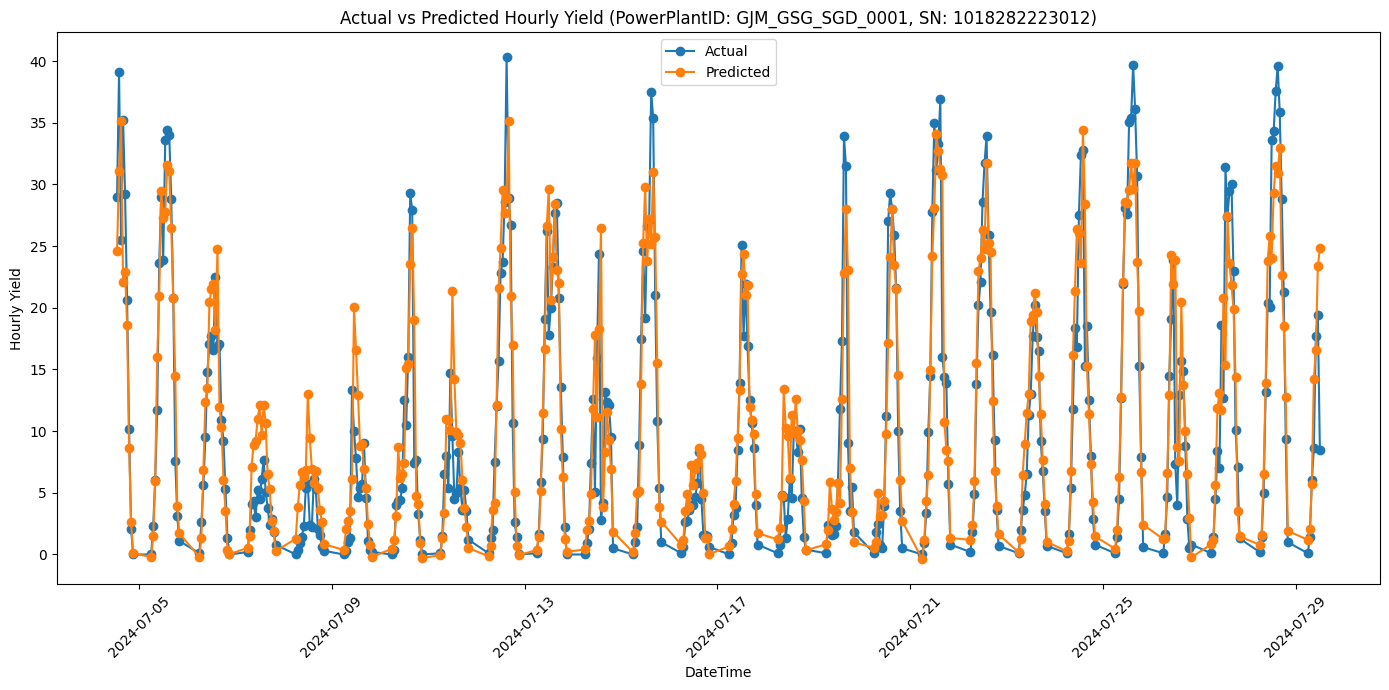

Daily MSE: 11.057314391648735
Daily RMSE: 3.3252540341526893
Daily MAE: 1.298930454853147
Daily R2: -3.4488289976874524
Daily MAPE: 131.20992045526216%
Daily MBD: 0.9587717488446189


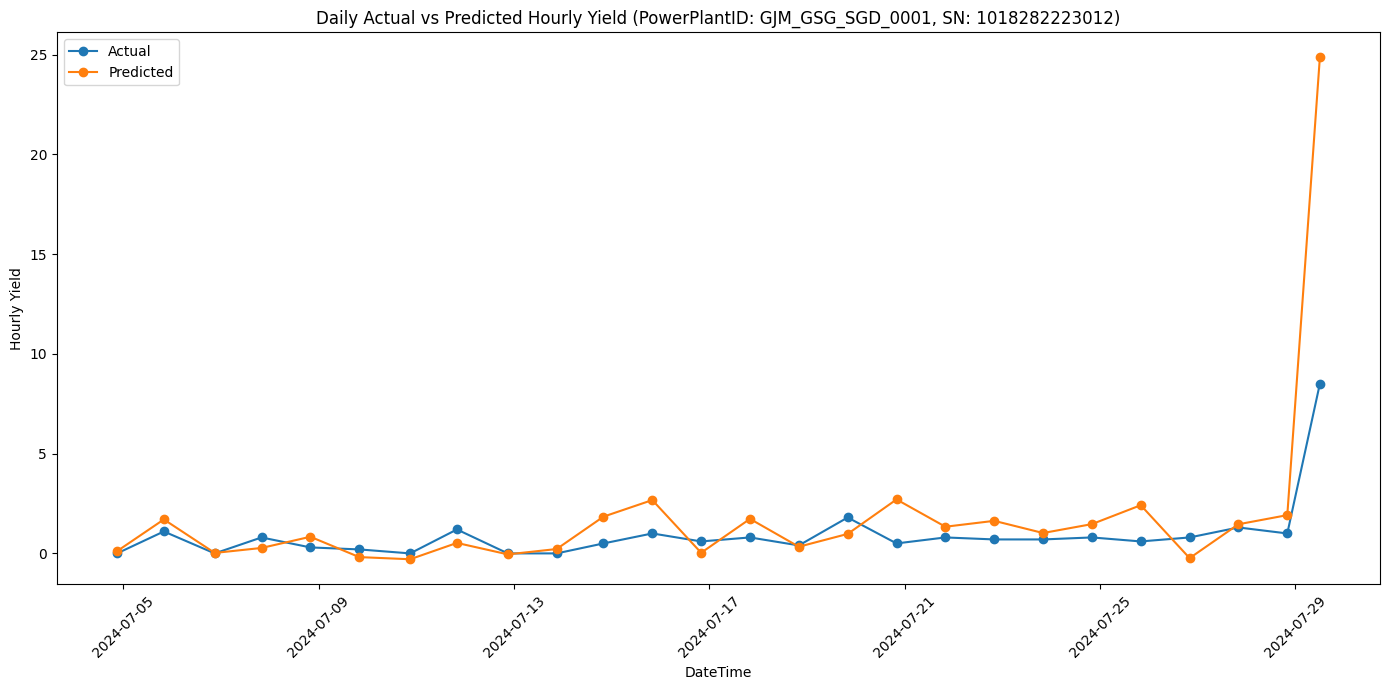


Inverter data for PowerPlantID: GJM_GSG_SGD_0001, SN: 1018282225009
       PowerPlantID             SN            datetime  DYield_diff  \
0  GJM_GSG_SGD_0001  1018282225009 2024-03-23 11:00:00         25.6   
1  GJM_GSG_SGD_0001  1018282225009 2024-03-23 12:00:00         33.1   
2  GJM_GSG_SGD_0001  1018282225009 2024-03-23 13:00:00         35.6   
3  GJM_GSG_SGD_0001  1018282225009 2024-03-23 14:00:00         37.0   
4  GJM_GSG_SGD_0001  1018282225009 2024-03-23 15:00:00         34.6   

             crt_dttm     solarpower_sn  rn1  sky   t1h   reh  ...  day  \
0 2024-03-23 10:55:03  GJM_GSG_SGD_0001  0.0    1  18.2  67.0  ...   23   
1 2024-03-23 11:55:03  GJM_GSG_SGD_0001  0.0    1  20.2  50.0  ...   23   
2 2024-03-23 12:55:03  GJM_GSG_SGD_0001  0.0    1  22.1  39.0  ...   23   
3 2024-03-23 13:55:03  GJM_GSG_SGD_0001  0.0    1  23.2  25.0  ...   23   
4 2024-03-23 14:55:03  GJM_GSG_SGD_0001  0.0    1  23.3  23.0  ...   23   

       hour_sin  hour_cos  month_sin     month_cos  y

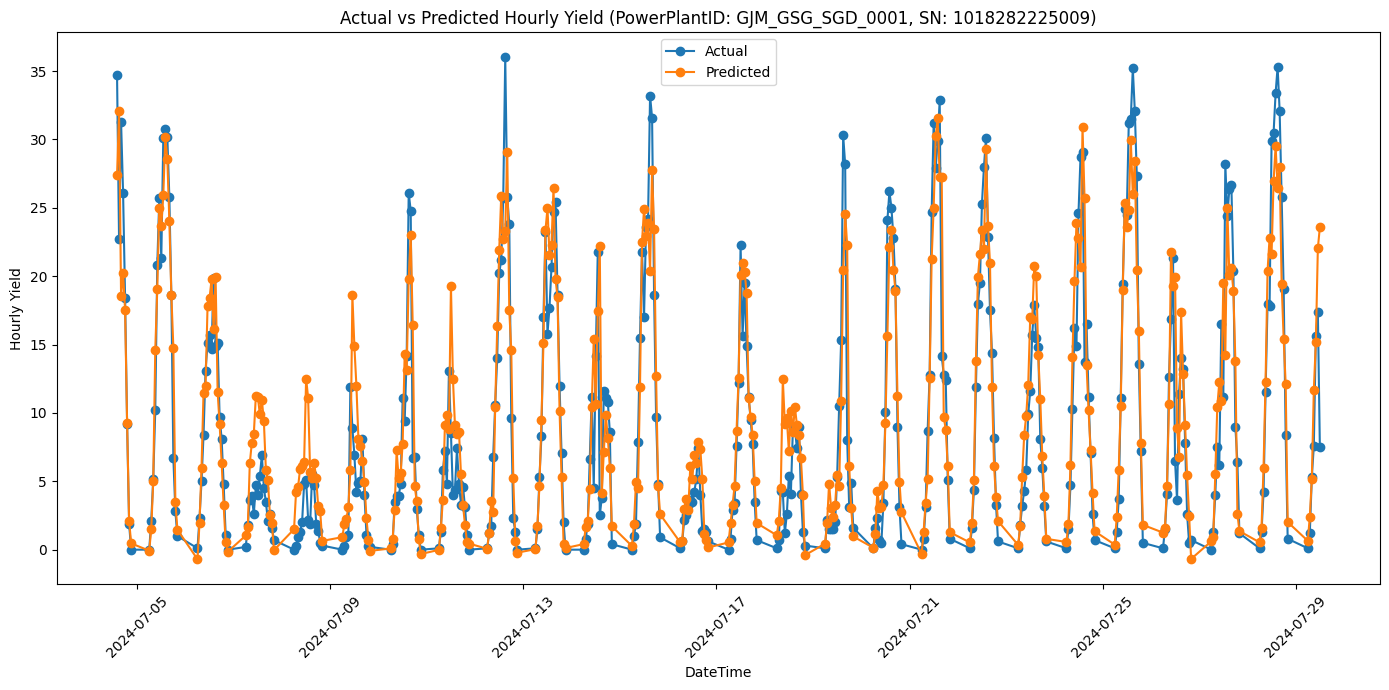

Daily MSE: 10.805687371573509
Daily RMSE: 3.287200537170422
Daily MAE: 1.3411927156937902
Daily R2: -4.508075633729983
Daily MAPE: 165.15273595575343%
Daily MBD: 0.966089820645332


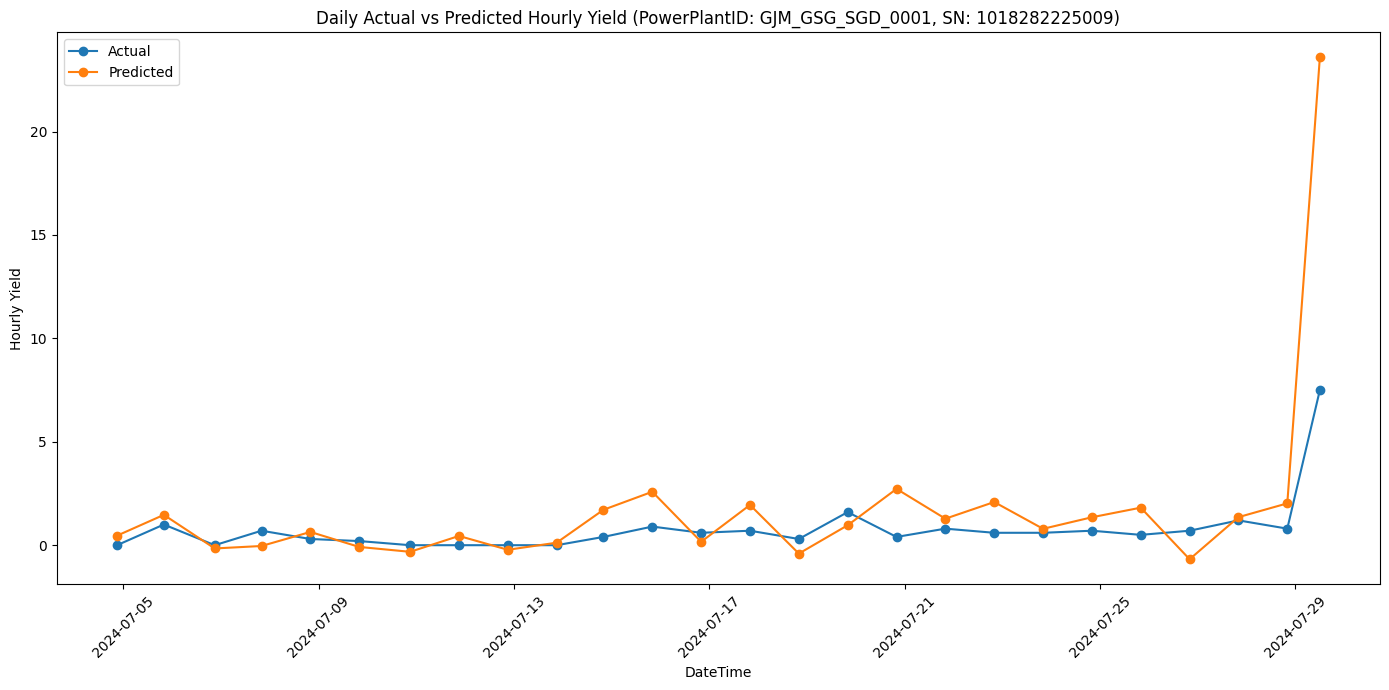


Results for YAG_HSM_SWR_0001_1015642044025:
             DateTime      PowerPlantID             SN            crt_dttm  \
0 2024-07-06 15:00:00  YAG_HSM_SWR_0001  1015642044025 2024-07-06 14:55:00   
1 2024-07-06 16:00:00  YAG_HSM_SWR_0001  1015642044025 2024-07-06 15:55:00   
2 2024-07-06 17:00:00  YAG_HSM_SWR_0001  1015642044025 2024-07-06 16:55:00   
3 2024-07-06 18:00:00  YAG_HSM_SWR_0001  1015642044025 2024-07-06 17:55:00   
4 2024-07-06 19:00:00  YAG_HSM_SWR_0001  1015642044025 2024-07-06 18:55:00   

   Actual  Predicted  Difference   Accuracy  
0     9.3   8.582345    0.717655  92.283278  
1     9.2   8.175624    1.024376  88.865480  
2     4.3   5.046952   -0.746952  82.629017  
3     8.8   2.784199    6.015801  31.638628  
4     4.4   2.502548    1.897452  56.876101  

Results for YAG_HSM_SWR_0001_1015642044102:
             DateTime      PowerPlantID             SN            crt_dttm  \
0 2024-07-06 14:00:00  YAG_HSM_SWR_0001  1015642044102 2024-07-06 13:55:03   
1 2024-07

In [83]:
import pandas as pd
import numpy as np
# from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import re
import joblib

# ==============================
# 1. 데이터 로드
# ==============================
solar_data_path = './태양광 발전량 예측 폴더/태양광_발전량데이터_24-07-29-11시.csv'
weather_data_path = './태양광 발전량 예측 폴더/태양광_날씨데이터_24-07-29-11시.csv'

solar_df = pd.read_csv(solar_data_path)
weather_df = pd.read_csv(weather_data_path)

# ==============================
# 2. 태양광 데이터 전처리
# ==============================
solar_df['crt_dttm'] = pd.to_datetime(solar_df['crt_dttm'], errors='coerce')
solar_df = solar_df.dropna(subset=['crt_dttm']).copy()

solar_df['datetime'] = solar_df['crt_dttm'].dt.floor('h')
solar_df['date'] = solar_df['crt_dttm'].dt.date

# 각 시간별 마지막 데이터 선택
hourly_solar = (
    solar_df
    .sort_values(by=['crt_dttm'])
    .groupby(['PowerPlantID', 'SN', 'datetime'])
    .last()
    .reset_index()
)

# 시간별 발전량 계산
hourly_solar['date'] = hourly_solar['datetime'].dt.date
hourly_solar['DYield_diff'] = (
    hourly_solar
    .groupby(['PowerPlantID', 'SN', 'date'])['DYield']
    .diff()
    .fillna(hourly_solar['DYield'])
)

# ------------------------------
# DYield_diff 이상치/음수 처리
# ------------------------------
# 음수는 계측 오류/리셋 가능성이 높으므로 0으로 클리핑
hourly_solar['DYield_diff'] = hourly_solar['DYield_diff'].clip(lower=0)

# 너무 큰 이상치는 상위 99.5% 기준으로 클리핑
upper_limit = hourly_solar['DYield_diff'].quantile(0.995)
hourly_solar['DYield_diff'] = hourly_solar['DYield_diff'].clip(upper=upper_limit)

# ==============================
# 3. 날씨 데이터 전처리
# ==============================
weather_df['base_time'] = weather_df['base_time'].apply(lambda x: f"{int(x):04d}")
weather_df['datetime'] = pd.to_datetime(
    weather_df['base_date'].astype(str) + weather_df['base_time'],
    format='%Y%m%d%H%M',
    errors='coerce'
)
weather_df = weather_df.dropna(subset=['datetime']).copy()
weather_df['datetime'] = weather_df['datetime'].dt.floor('h')

# 필요한 컬럼 선택
solar_selected = hourly_solar[['PowerPlantID', 'SN', 'datetime', 'DYield_diff', 'crt_dttm']]
weather_selected = weather_df[['solarpower_sn', 'datetime', 'rn1', 'sky', 't1h', 'reh', 'rn1v', 'wsd']].copy()

# ==============================
# 4. 시간 병합
# ==============================
merged_df = pd.merge(
    solar_selected,
    weather_selected,
    left_on=['PowerPlantID', 'datetime'],
    right_on=['solarpower_sn', 'datetime'],
    how='inner'
)

# 현재 코드의 의도를 유지: 시간 라벨을 1시간 뒤로 재해석
merged_df['datetime'] = merged_df['datetime'] + pd.Timedelta(hours=1)

# ==============================
# 5. 결측/문자 처리
# ==============================
# rn1v 처리
merged_df['rn1v'] = merged_df['rn1v'].replace('\\N', np.nan)
merged_df['rn1v'] = pd.to_numeric(merged_df['rn1v'], errors='coerce').fillna(0)

# 숫자형으로 변환할 수 있는 컬럼들
for col in ['sky', 't1h', 'reh', 'wsd']:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

# 강수량 변환 함수
def convert_pcp(value):
    value = str(value)

    if '강수없음' in value:
        return 0.0
    elif '미만' in value:
        num = re.findall(r'\d+', value)
        if num:
            return float(num[0]) - 0.5
        else:
            return 0.0
    else:
        num = re.findall(r'\d+\.\d+|\d+', value)
        if num:
            return float(num[0])
        else:
            return 0.0

merged_df['rn1'] = merged_df['rn1'].apply(convert_pcp)

# 남은 결측 제거
merged_df = merged_df.dropna(subset=['sky', 't1h', 'reh', 'wsd']).copy()

# ==============================
# 6. 시간 피처 생성
# ==============================
merged_df['hour'] = merged_df['datetime'].dt.hour
merged_df['month'] = merged_df['datetime'].dt.month
merged_df['day'] = merged_df['datetime'].dt.day

# 주기성 피처
merged_df['hour_sin'] = np.sin(2 * np.pi * merged_df['hour'] / 24)
merged_df['hour_cos'] = np.cos(2 * np.pi * merged_df['hour'] / 24)
merged_df['month_sin'] = np.sin(2 * np.pi * merged_df['month'] / 12)
merged_df['month_cos'] = np.cos(2 * np.pi * merged_df['month'] / 12)

# ==============================
# 7. 인버터별 모델 학습
# ==============================
inverters = {
    'YAG_HSM_SWR_0001': [1015642044025, 1015642044102, 1015642044093],
    'GJM_GSG_SGD_0001': [1018282223012, 1018282225009]
}

results_dict = {}

for plant_id, sn_list in inverters.items():
    for sn in sn_list:
        inverter_data = merged_df[
            (merged_df['PowerPlantID'] == plant_id) &
            (merged_df['SN'] == sn)
        ].copy()

        # 시간순 정렬
        inverter_data = inverter_data.sort_values('datetime').reset_index(drop=True)

        # ------------------------------
        # lag feature 추가
        # ------------------------------
        inverter_data['yield_lag1'] = inverter_data['DYield_diff'].shift(1)
        inverter_data['yield_lag2'] = inverter_data['DYield_diff'].shift(2)
        inverter_data['yield_lag24'] = inverter_data['DYield_diff'].shift(24)

        # rolling feature (누수 방지 위해 shift 후 rolling)
        inverter_data['yield_roll3'] = inverter_data['DYield_diff'].shift(1).rolling(3).mean()
        inverter_data['yield_roll6'] = inverter_data['DYield_diff'].shift(1).rolling(6).mean()

        # lag/rolling 생성 후 결측 제거
        inverter_data = inverter_data.dropna().reset_index(drop=True)

        if len(inverter_data) < 50:
            print(f"Not enough data for PowerPlantID: {plant_id}, SN: {sn}. Skipping. Sample: {len(inverter_data)}")
            continue

        print(f'\nInverter data for PowerPlantID: {plant_id}, SN: {sn}')
        print(inverter_data.head())

        # 피처 선택
        feature_cols = [
            'rn1', 'sky', 't1h', 'reh', 'rn1v', 'wsd',
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
            'yield_lag1', 'yield_lag2', 'yield_lag24',
            'yield_roll3', 'yield_roll6'
        ]

        X = inverter_data[feature_cols]
        y = inverter_data['DYield_diff']

        # ------------------------------
        # 시간순 분할 (랜덤 분할 제거)
        # ------------------------------
        split_idx = int(len(inverter_data) * 0.8)

        train_data = inverter_data.iloc[:split_idx].copy()
        test_data = inverter_data.iloc[split_idx:].copy()

        X_train = train_data[feature_cols]
        y_train = train_data['DYield_diff']

        X_test = test_data[feature_cols]
        y_test = test_data['DYield_diff']

        if len(X_train) == 0 or len(X_test) == 0:
            print(f"Train/Test split failed for PowerPlantID: {plant_id}, SN: {sn}")
            continue

        # # ------------------------------
        # # RandomForest 모델 학습
        # # ------------------------------
        # model = RandomForestRegressor(
        #     n_estimators=500,
        #     max_depth=None,
        #     min_samples_split=5,
        #     min_samples_leaf=2,
        #     max_features=0.7,
        #     random_state=42,
        #     n_jobs=-1,
        #     verbose=1
        # )

        # model.fit(X_train, y_train)

        # ------------------------------
        # LGBM 모델 학습
        # ------------------------------

        # 무난하게 시작       
        # model = LGBMRegressor(
        #     n_estimators=300,
        #     learning_rate=0.05,
        #     num_leaves=20,
        #     subsample=0.8,
        #     colsample_bytree=0.8,
        #     random_state=42,
        #     n_jobs=-1
        # )
        
        # 좀 더 추가
        model = LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric='l2'
        )

        # 모델 저장
        # model_filename = f'./태양광 발전량 예측 폴더/model_{plant_id}_{sn}.joblib'
        # joblib.dump(model, model_filename)

        # 예측
        y_pred = model.predict(X_test)

        # ------------------------------
        # 평가
        # ------------------------------
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        non_zero_actuals = y_test != 0
        if non_zero_actuals.sum() > 0:
            mape = np.mean(np.abs((y_test[non_zero_actuals] - y_pred[non_zero_actuals]) / y_test[non_zero_actuals])) * 100
        else:
            mape = np.nan

        mbd = np.mean(y_pred - y_test)

        print(f'PowerPlantID: {plant_id}, SN: {sn}')
        print(f'MSE: {mse}')
        print(f'RMSE: {rmse}')
        print(f'MAE: {mae}')
        print(f'R2: {r2}')
        print(f'MAPE: {mape}%')
        print(f'MBD: {mbd}')

        # 결과 저장
        results_df = pd.DataFrame({
            'DateTime': test_data['datetime'].values,
            'PowerPlantID': test_data['PowerPlantID'].values,
            'SN': test_data['SN'].values,
            'crt_dttm': test_data['crt_dttm'].values,
            'Actual': y_test.values,
            'Predicted': y_pred
        }).reset_index(drop=True)

        results_dict[f'{plant_id}_{sn}'] = results_df

        # 정렬
        results_df = results_df.sort_values(by='DateTime').reset_index(drop=True)

        # ------------------------------
        # 시각화 (시간 단위)
        # ------------------------------
        plt.figure(figsize=(14, 7))
        plt.plot(results_df['DateTime'], results_df['Actual'], label='Actual', marker='o')
        plt.plot(results_df['DateTime'], results_df['Predicted'], label='Predicted', marker='o')
        plt.legend()
        plt.xlabel('DateTime')
        plt.ylabel('Hourly Yield')
        plt.title(f'Actual vs Predicted Hourly Yield (PowerPlantID: {plant_id}, SN: {sn})')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ------------------------------
        # 일 단위 마지막 시점 평가
        # ------------------------------
        results_df['Date'] = pd.to_datetime(results_df['DateTime']).dt.date

        last_results_df = (
            results_df
            .sort_values(by=['DateTime'])
            .groupby(['PowerPlantID', 'SN', 'Date'])
            .last()
            .reset_index()
        )

        last_results_df = last_results_df.drop(columns=['Date'])
        last_results_df = last_results_df.sort_values(by='DateTime').reset_index(drop=True)

        non_zero_daily = last_results_df['Actual'] != 0

        mse = mean_squared_error(last_results_df['Actual'], last_results_df['Predicted'])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(last_results_df['Actual'], last_results_df['Predicted'])
        r2 = r2_score(last_results_df['Actual'], last_results_df['Predicted'])

        if non_zero_daily.sum() > 0:
            mape = np.mean(
                np.abs(
                    (last_results_df.loc[non_zero_daily, 'Actual'] - last_results_df.loc[non_zero_daily, 'Predicted'])
                    / last_results_df.loc[non_zero_daily, 'Actual']
                )
            ) * 100
        else:
            mape = np.nan

        mbd = np.mean(last_results_df['Predicted'] - last_results_df['Actual'])

        print(f'Daily MSE: {mse}')
        print(f'Daily RMSE: {rmse}')
        print(f'Daily MAE: {mae}')
        print(f'Daily R2: {r2}')
        print(f'Daily MAPE: {mape}%')
        print(f'Daily MBD: {mbd}')

        # ------------------------------
        # 시각화 (일 단위)
        # ------------------------------
        plt.figure(figsize=(14, 7))
        plt.plot(last_results_df['DateTime'], last_results_df['Actual'], label='Actual', marker='o')
        plt.plot(last_results_df['DateTime'], last_results_df['Predicted'], label='Predicted', marker='o')
        plt.legend()
        plt.xlabel('DateTime')
        plt.ylabel('Hourly Yield')
        plt.title(f'Daily Actual vs Predicted Hourly Yield (PowerPlantID: {plant_id}, SN: {sn})')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# ==============================
# 8. 결과 확인
# ==============================
for key, df in results_dict.items():
    df['Difference'] = df['Actual'] - df['Predicted']
    df['Accuracy'] = np.where(
        df['Actual'] == 0,
        0,
        (1 - np.abs(df['Difference']) / np.abs(df['Actual'])) * 100
    )

    print(f"\nResults for {key}:")
    print(df.head())

In [84]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

        feature  importance
10   yield_lag1        4691
2           t1h        3595
11   yield_lag2        3567
14  yield_roll6        3330
13  yield_roll3        3037
3           reh        2916
12  yield_lag24        2901
5           wsd        2483
7      hour_cos        1092
6      hour_sin         809
1           sky         651
8     month_sin         508
9     month_cos         174
0           rn1         144
4          rn1v         102


In [85]:
results_df['hour'] = pd.to_datetime(results_df['DateTime']).dt.hour

hour_summary = results_df.groupby('hour')[['Actual', 'Predicted']].mean()
print(hour_summary)

         Actual  Predicted
hour                      
6      0.068000   0.430253
7      1.248000   1.747448
8      3.424000   4.523449
9      6.536000   8.182855
10    10.252000  11.654917
11    13.252000  15.456326
12    14.348000  17.353721
13    16.941667  17.347392
14    18.940000  19.355855
15    19.856000  18.916696
16    18.128000  17.065840
17    12.772000  13.192060
18     7.808000   8.535414
19     3.956000   4.354575
20     0.860000   1.072257
21     0.000000   0.055116


In [86]:
results_df['abs_error'] = np.abs(results_df['Actual'] - results_df['Predicted'])
print(results_df.groupby('hour')['abs_error'].mean())

hour
6     0.473575
7     0.682768
8     1.398108
9     2.891514
10    2.739976
11    3.488146
12    5.330212
13    5.523782
14    3.254576
15    5.077304
16    3.676681
17    3.305013
18    2.354813
19    1.489218
20    0.836759
21    0.287896
Name: abs_error, dtype: float64
